# Case Study 3 — vehicle damage in claim photos with a fine-tuned vision model

This notebook sorts photos of damaged cars into six damage types, compares the fine-tuned GPT-4o of the article with the general models of 2026, and ends with an exercise that shows how easily such a photo can be faked.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/05_cs3_vehicle_damage_vision/05_cs3_vehicle_damage_vision.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

The case study, its system prompts and its output schemas come from the published article, whose research notebook this one re-implements in the seminar's own style:

> Hatzesberger S, Nonneman I (2026) Advanced applications of generative AI in actuarial science: case studies beyond ChatGPT. *European Actuarial Journal* 16(2):481–523. https://doi.org/10.1007/s13385-026-00464-9

**The business case.** At first notice of loss, a motor claim increasingly arrives with photos taken on a phone. Someone has to look at them: what is damaged, how badly, whether the photo is good enough to judge, and whether the claim needs an assessor or can go straight to a repair partner. A model that sorts photos by damage type is a first step towards that triage. A label on its own misses most of what a claims handler needs — where the damage is, how severe it is, whether there is more than one kind — and it says nothing about whether the photo is genuine. The article's case study on vehicle damage covers the label and the location; this notebook adds severity, review rules and a look at faked photos.

**How this notebook runs.** Like the research notebook, it uses nothing but the plain `openai` package; where the research notebook used the chat interface, this one uses the Responses API of `01` and `02`. Like the other notebooks, it **ships with its outputs**: every live answer below was produced by running it on 23 September 2026, and section 6 reads 900 predictions from the research notebook's saved run of March 2025 and 1,200 recorded for this notebook on 22 September 2026. Running it yourself needs an OpenAI key, and a full run from scratch cost USD 0.13 at list prices. While your key can reach the models, every cell that calls a model calls it live, and a live rerun gives answers that differ here and there from the saved ones. Where a model is not available to your key, the cells that classify photos fall back to its base model or to the answers recorded in the run saved here, and say which.

## Learning objectives

After working through this notebook you will be able to:

- **explain** how a photo reaches a vision model — base64, a data URL and the `detail` setting — and what it costs in tokens;
- **classify** a claim photo into the article's six damage classes with a structured output, on the article's fine-tuned GPT-4o and on today's general models;
- **evaluate** classifiers on 300 test photos — and on the 205 of them without a near-copy among the training photos — with accuracy, weighted and macro F1, bootstrap intervals and confusion matrices, and say what fine-tuning fixed and what it broke;
- **judge** whether a fine-tune from 2025 still earns its price against the models of 2026;
- **extract** more than a label — location, severity, image quality — and turn it into deterministic review rules;
- **recognise** how cheaply a damage photo can be faked, and what provenance data can and cannot tell an insurer.

## Contents

1. [Setup](#1-setup)
2. [The data](#2-the-data)
3. [The split: which photos the fine-tune has seen](#3-the-split-which-photos-the-fine-tune-has-seen)
4. [One photo, one call](#4-one-photo-one-call)
5. [Twelve photos, three models, live](#5-twelve-photos-three-models-live)
6. [Evaluation on 300 test photos](#6-evaluation-on-300-test-photos)
7. [More than a label](#7-more-than-a-label)
8. [What to take away](#8-what-to-take-away)
9. [Extra exercise: faking the damage](#9-extra-exercise-faking-the-damage)

**Cost.** A full run from scratch cost USD 0.13 at list prices when the saved outputs were produced on 23 September 2026: 79 paid calls, the largest items being the location experiment of section 7 (USD 0.06) and the two synthetic images of section 9 (USD 0.02). The 1,200 predictions of 2026 evaluated in section 6 were recorded once, on 22 September 2026, for USD 1.35, and are read from `data/`; they are repeated only if you switch `RECORD_PREDICTIONS` on. The downloads — the label file and twelve photos — are kept in `_local/` next to the notebook, so a second run fetches nothing again. In Colab, `_local/` lives on the temporary machine and is lost when the session ends.

---

## 1 Setup

Two cells, run once. The first makes sure the packages are there; the second fixes the models and their prices, finds your key without ever printing it, sets up a ledger that records the tokens and the cost of every paid call, and asks OpenAI which of the models your key can see.

Colab already provides every package this notebook uses — `openai`, `pydantic`, `kagglehub`, `pandas`, `scikit-learn`, `matplotlib` and `Pillow` among them. The cell below installs a package, at its pinned version, only if its import fails, and it compares every installed version with its pin. The saved outputs were produced with the versions it prints — among them openai 2.29.0 rather than the pinned 3.14.0, with which this notebook has not been run — so read an `[ATTENTION]` there as information, not as an error.

In [1]:
# Colab already ships every package this notebook uses. A package is installed, at its pinned version,
# only if its import fails - on Colab and on a local install from requirements.txt nothing is installed.
import importlib.util

PINS = {
    "openai": "openai==3.14.0",
    "pydantic": "pydantic==2.13.5",
    "kagglehub": "kagglehub==0.3.12",
    "requests": "requests==2.32.5",
    "numpy": "numpy==2.1.3",
    "pandas": "pandas==2.2.3",
    "sklearn": "scikit-learn==1.6.1",
    "matplotlib": "matplotlib==3.10.0",
    "PIL": "pillow==11.3.0",
}
missing = " ".join(pin for module, pin in PINS.items() if importlib.util.find_spec(module) is None)
if missing:
    %pip install -q {missing}

import kagglehub, matplotlib, numpy, openai, pandas, PIL, pydantic, requests, sklearn

MODULES = {"openai": openai, "pydantic": pydantic, "kagglehub": kagglehub, "requests": requests, "numpy": numpy,
           "pandas": pandas, "sklearn": sklearn, "matplotlib": matplotlib, "PIL": PIL}
mismatches = 0
for module_name, pin in PINS.items():
    name, pinned = pin.split("==")
    installed = MODULES[module_name].__version__
    if installed == pinned:
        print(f"[PASS]      {name:<13} {installed}")
    else:
        mismatches += 1
        print(f"[ATTENTION] {name:<13} installed {installed}, pinned {pinned}")
if mismatches:
    print(f"{mismatches} of {len(PINS)} packages differ from their pins. The notebook usually runs regardless; if a cell")
    print("fails, install the pinned versions from the repository's requirements.txt and restart the session.")

[ATTENTION] openai        installed 2.29.0, pinned 3.14.0
[ATTENTION] pydantic      installed 2.11.4, pinned 2.13.5
[PASS]      kagglehub     0.3.12
[PASS]      requests      2.32.5
[ATTENTION] numpy         installed 2.4.6, pinned 2.1.3
[PASS]      pandas        2.2.3
[PASS]      scikit-learn  1.6.1
[ATTENTION] matplotlib    installed 3.10.3, pinned 3.10.0
[ATTENTION] pillow        installed 12.3.0, pinned 11.3.0
5 of 9 packages differ from their pins. The notebook usually runs regardless; if a cell
fails, install the pinned versions from the repository's requirements.txt and restart the session.


A few words on the models before the cell that fixes them.

| Role | Identifier | `temperature` |
| --- | --- | --- |
| The article's fine-tuned model | `ft:gpt-4o-2024-08-06:personal::B5swMoBf` | 0 |
| Its base model, used zero-shot | `gpt-4o-2024-08-06` | 0 |
| Today's general model | `gpt-6-luna` | not sent: rejected at its default effort |
| Benchmark only, section 6 | `gpt-5.4-mini-2026-03-17` | 0, at reasoning effort `none` |
| Image generation, section 9 | `gpt-image-2.5-sunburst` | — |

- **The fine-tune** was trained in February 2025 for the article's research notebook, on 900 training photos and 300 validation photos of the data set used here. A fine-tuned model lives in the OpenAI organisation that trained it. The seminar key belongs to the lecturer's organisation, so in the room you can call it; outside the seminar other keys cannot see it, and every cell that needs it falls back to its base model or to recorded answers, and says which.
- **GPT-6 Luna** was released on 22 September 2026 and is the cheapest model of the GPT-6 family. It exists only under this alias, not as a dated snapshot, so its behaviour may change without its name changing. **`gpt-image-2.5-sunburst`** was released on 8 September 2026.
- **Temperature.** The research notebook left `temperature` at its default. Here we set it to 0 wherever a model accepts it — GPT-4o, its fine-tune, and GPT-5.4 mini, which accepts it only at reasoning effort `none`, its default — to make the answers as repeatable as the API allows. GPT-6 Luna accepts it only at reasoning effort `none`; here it runs at its default effort, `medium`, at which it rejects the parameter and manages its own sampling.
- **Prices** are OpenAI's list prices, retrieved from its pricing page on 22 September 2026. Inference on a fine-tuned GPT-4o costs one and a half times the price of the base model, and GPT-6 Luna charges USD 0.125 per million input tokens written to the prompt cache, against USD 0.10 per million for plain input. The saved run's costs were computed before cache writes were counted, which changes none of them: only requests of at least 1,024 tokens are cached or written, and every GPT-6 Luna request in this notebook, the 300 recorded in section 6 included, is shorter (626 tokens per photo, 694 for the assessment of section 7).

In [2]:
import base64
import io
import json
import logging
import os
import random
import re
import struct
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from contextlib import redirect_stderr
from pathlib import Path
from typing import Literal, Optional

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
import requests
from openai import OpenAI
from PIL import Image
from pydantic import BaseModel, Field
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# The models of this notebook.
MODEL_FINETUNED = "ft:gpt-4o-2024-08-06:personal::B5swMoBf"  # the article's fine-tune, in the lecturer's organisation
MODEL_BASE = "gpt-4o-2024-08-06"                            # its base model, used zero-shot
MODEL_NOW = "gpt-6-luna"                                    # today's general model (alias, no dated snapshot)
MODEL_BENCH = "gpt-5.4-mini-2026-03-17"                     # benchmark only, section 6
MODEL_IMAGE = "gpt-image-2.5-sunburst"                      # image generation and editing, section 9
MODEL_LABELS = {MODEL_BASE: "GPT-4o zero-shot", MODEL_FINETUNED: "GPT-4o fine-tuned",
                MODEL_NOW: "GPT-6 Luna", MODEL_BENCH: "GPT-5.4 mini", MODEL_IMAGE: "GPT Image 2.5 Sunburst"}

# List prices in USD per million tokens: (input, cached input, cache write, output).
# OpenAI pricing page, standard processing, as retrieved on 22 September 2026. Only GPT-6 Luna has a
# cache-write price: for the other models a write costs the input price.
PRICES_USD_PER_MTOK = {
    MODEL_FINETUNED: (3.75, 1.875, None, 15.00),  # inference on a fine-tuned gpt-4o-2024-08-06
    MODEL_BASE: (2.50, 1.25, None, 10.00),
    MODEL_NOW: (0.10, 0.01, 0.125, 0.50),
    MODEL_BENCH: (0.75, 0.075, None, 4.50),
}
# The image model bills text and image tokens at different prices (USD per million tokens).
IMAGE_PRICES_USD_PER_MTOK = {"text in": 5.00, "image in": 8.00, "image out": 30.00}

# Sampling options per model: temperature=0 wherever a model accepts it. GPT-5.4 mini accepts it only at
# reasoning effort "none", its default, which is passed explicitly. GPT-6 Luna runs at its default
# effort, "medium", at which it rejects the parameter.
SAMPLING_OPTIONS = {
    MODEL_FINETUNED: {"temperature": 0},
    MODEL_BASE: {"temperature": 0},
    MODEL_BENCH: {"temperature": 0, "reasoning": {"effort": "none"}},
}

SEED = 42
LABELS = ["crack", "scratch", "tire flat", "dent", "glass shatter", "lamp broken"]  # label ids 0-5, the article's order

# The data set on Kaggle, pinned to its version 1. Single files download without a Kaggle account.
KAGGLE_HANDLE = "imnandini/analytics-vidya-ripik-ai-hackfest/versions/1"

# Downloads and caches live in _local/ next to this notebook; the small committed results in data/.
LOCAL_DIR = Path("_local")
DATA_DIR = Path("data")
RAW_DATA_URL = ("https://raw.githubusercontent.com/simonhatzesberger/advanced-genai-actuarial/main/"
                "notebooks/05_cs3_vehicle_damage_vision/data/")
LOCAL_DIR.mkdir(exist_ok=True)
os.environ.setdefault("KAGGLEHUB_CACHE", str(LOCAL_DIR / "kagglehub"))  # where kagglehub keeps what it downloads
logging.getLogger("kagglehub").setLevel(logging.ERROR)                  # no log line for every file it fetches


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
# Retries are handled by with_retry() below, so that you can see them; the client itself does not retry.
client = OpenAI(api_key=key, max_retries=0, timeout=180) if key else None

LEDGER: list[dict] = []  # one row per paid API call made in this session


def log_usage(model: str, purpose: str, input_tokens: int, cached_tokens: int = 0, output_tokens: int = 0,
              cost: float | None = None, cache_write_tokens: int = 0) -> float:
    """Record one paid call in the ledger and return its cost in USD at the list prices above."""
    if cost is None:
        price_in, price_cached, price_write, price_out = PRICES_USD_PER_MTOK[model]
        if price_write is None:  # no cache-write price: a write costs the input price
            price_write = price_in
        cost = ((input_tokens - cached_tokens - cache_write_tokens) * price_in + cached_tokens * price_cached
                + cache_write_tokens * price_write + output_tokens * price_out) / 1e6
    LEDGER.append({"purpose": purpose, "model": model, "input_tokens": input_tokens, "cached_tokens": cached_tokens,
                   "cache_write_tokens": cache_write_tokens, "output_tokens": output_tokens, "cost_usd": cost})
    return cost


def spend_report() -> pd.DataFrame:
    """Calls, tokens and cost of everything this session has paid for, by purpose and model."""
    columns = ["calls", "input_tokens", "cached_tokens", "cache_write_tokens", "output_tokens", "cost_usd"]
    if not LEDGER:
        return pd.DataFrame(columns=columns)
    table = (
        pd.DataFrame(LEDGER)
        .groupby(["purpose", "model"], sort=False)
        .agg(calls=("cost_usd", "size"), input_tokens=("input_tokens", "sum"), cached_tokens=("cached_tokens", "sum"),
             cache_write_tokens=("cache_write_tokens", "sum"), output_tokens=("output_tokens", "sum"),
             cost_usd=("cost_usd", "sum"))
    )
    table.loc[("total", ""), :] = table.sum()
    table[columns[:5]] = table[columns[:5]].astype(int)
    return table.round({"cost_usd": 4})


RETRYABLE = (openai.RateLimitError, openai.APIConnectionError, openai.APITimeoutError, openai.InternalServerError)
NO_CREDIT = {"flag": False}  # set once the key reports that it has no credit left


def with_retry(call, attempts: int = 6, first_wait: float = 2.0):
    """Run call(). On a rate limit or a transient server error wait 2, 4, 8, ... seconds, plus a random
    fraction of a second so that parallel calls do not retry in lockstep, and try again. A key without
    credit is not retried: waiting would not help."""
    for attempt in range(1, attempts + 1):
        try:
            return call()
        except RETRYABLE as exc:
            if getattr(exc, "code", None) == "insufficient_quota":
                NO_CREDIT["flag"] = True
                raise
            if attempt == attempts:
                raise
            time.sleep(first_wait * 2 ** (attempt - 1) + random.uniform(0, 1))


def can_call(model: str) -> bool:
    # A model is called live if this key can see it and still has credit; otherwise recorded answers are used.
    return AVAILABLE.get(model, False) and not NO_CREDIT["flag"]


def short_error(exc: Exception) -> str:
    """A one-line description of a failed call that never repeats a key, not even a masked one."""
    text = re.sub(r"sk-[A-Za-z0-9_\-*]{4,}", "sk-***", " ".join(str(exc).split()))
    return f"{type(exc).__name__}: {text[:160]}"


def load_data_file(name: str) -> Path | None:
    """A small result file of this notebook: from data/ next to it, else downloaded once from GitHub into
    _local/data/. The download is written to a temporary name and renamed when complete."""
    local = DATA_DIR / name
    if local.exists():
        return local
    cached = LOCAL_DIR / "data" / name
    if cached.exists():
        return cached
    try:
        response = requests.get(RAW_DATA_URL + name, timeout=60)
        response.raise_for_status()
        cached.parent.mkdir(parents=True, exist_ok=True)
        partial = cached.with_name(cached.name + ".part")
        partial.write_bytes(response.content)
        os.replace(partial, cached)  # atomic: the file appears under its name only once it is complete
        return cached
    except Exception as exc:
        reason = f"HTTP {exc.response.status_code}" if isinstance(exc, requests.HTTPError) else short_error(exc)
        print(f"[ATTENTION] data/{name} is not next to this notebook and could not be downloaded from GitHub ({reason}).")
        return None


if key:
    print(f"[PASS] A key named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No key named OPENAI_API_KEY is visible to this notebook.")
    print("            Every model call below needs one; notebook 00, section 6 explains how.")
    print("            Without one, the cells show the answers recorded in the run saved here instead.")

# Which models can this key use? Looking a model up costs nothing.
AVAILABLE = {}
for model in [MODEL_FINETUNED, MODEL_BASE, MODEL_NOW, MODEL_BENCH, MODEL_IMAGE]:
    if client is None:
        AVAILABLE[model] = False
        continue
    try:
        client.models.retrieve(model)
        AVAILABLE[model] = True
        print(f"[PASS]      {model:<40} available to this key")
    except openai.NotFoundError:
        AVAILABLE[model] = False
        print(f"[ATTENTION] {model:<40} not visible to this key - its cells use recorded answers")
    except Exception as exc:
        AVAILABLE[model] = False
        print(f"[ATTENTION] {model:<40} could not be checked ({short_error(exc)})")

print(f"Local cache : {LOCAL_DIR}/ (next to where the notebook runs), for downloads and generated images")

[PASS] A key named OPENAI_API_KEY is visible (164 characters long).
       Its value is never printed - not here, not anywhere.
[PASS]      ft:gpt-4o-2024-08-06:personal::B5swMoBf  available to this key
[PASS]      gpt-4o-2024-08-06                        available to this key
[PASS]      gpt-6-luna                               available to this key
[PASS]      gpt-5.4-mini-2026-03-17                  available to this key
[PASS]      gpt-image-2.5-sunburst                   available to this key
Local cache : _local/ (next to where the notebook runs), for downloads and generated images


---

## 2 The data

### Why it matters for actuaries

A classifier is only as good as the photos it learns from and is judged on. Before any model sees a photo, it is worth knowing what the photos look like, how the labels are spread across the classes, and which of them are hard even for a human. The class shares decide which metric is honest: with a rare class, a model can reach a high accuracy while failing on that class completely.

The data set is the one of the article: 7,200 labelled photos of damaged cars from the Analytics Vidhya × Ripik.AI HackFest (1–3 December 2023), published on Kaggle by the user imnandini under a declared Apache 2.0 licence (the uploader's declaration). Each photo carries one of six labels. The whole data set is 1.6 GB; this notebook downloads only what it needs — the label file and twelve photos — one file at a time, through `kagglehub`. Single files need no Kaggle account.

### 2.1 The labels

In [3]:
def kaggle_files(paths_in_dataset: list[str], workers: int = 6) -> list[Path]:
    """Local paths of single files of the data set, downloaded on first use. kagglehub keeps them in
    _local/kagglehub/ and marks a file complete only once its download has finished (checking the
    checksum where the server sends one), so an interrupted download is fetched again rather than
    mistaken for a finished one. A failed download is tried three times, after 2 and 4 seconds."""
    def fetch(path: str) -> Path:
        for attempt in range(1, 4):
            try:
                return Path(kagglehub.dataset_download(KAGGLE_HANDLE, path=path))
            except Exception:
                if attempt == 3:
                    raise
                time.sleep(2 * 2 ** (attempt - 1))

    try:
        with redirect_stderr(io.StringIO()), ThreadPoolExecutor(max_workers=workers) as pool:  # no progress bars
            return list(pool.map(fetch, paths_in_dataset))
    except Exception as exc:
        print(f"[ATTENTION] A file could not be downloaded from Kaggle ({short_error(exc)}).")
        print("            Run this cell again in a minute; files already downloaded are kept in _local/.")
        raise SystemExit("Stopped: a download from Kaggle failed.") from None


started = time.perf_counter()
(csv_path,) = kaggle_files(["train/train/train.csv"])
labels_raw = pd.read_csv(csv_path)
print(f"train.csv: {len(labels_raw):,} rows, columns {list(labels_raw.columns)} "
      f"({csv_path.stat().st_size:,} bytes, ready after {time.perf_counter() - started:.1f} seconds)")

# As in the research notebook: the label ids 1-6 become 0-5, and every id gets its name.
df = labels_raw.rename(columns={"label": "label_id"})
df["label_id"] = df["label_id"] - 1
df["label"] = df["label_id"].map(dict(enumerate(LABELS)))
assert df["label"].notna().all(), "a label id outside 1-6"
df[["image_id", "filename", "label_id", "label"]].head(8)

train.csv: 7,200 rows, columns ['image_id', 'filename', 'label'] (113,010 bytes, ready after 2.2 seconds)


,image_id,filename,label_id,label
0,1,1.jpg,1,scratch
1,2,2.jpg,3,dent
2,3,3.jpg,1,scratch
3,4,4.jpg,2,tire flat
4,5,5.jpg,4,glass shatter
5,6,6.jpg,1,scratch
6,7,7.jpg,4,glass shatter
7,8,8.jpg,4,glass shatter


One row per photo: a file name and a label id. Everything a model will be judged on is in the `label` column — one human judgement per photo, and nothing about where the damage is or how severe it is.

### 2.2 Six classes, far from balanced

,label id,photos,share
crack,0,171,2.4%
scratch,1,2349,32.6%
tire flat,2,534,7.4%
dent,3,2079,28.9%
glass shatter,4,1185,16.5%
lamp broken,5,882,12.2%


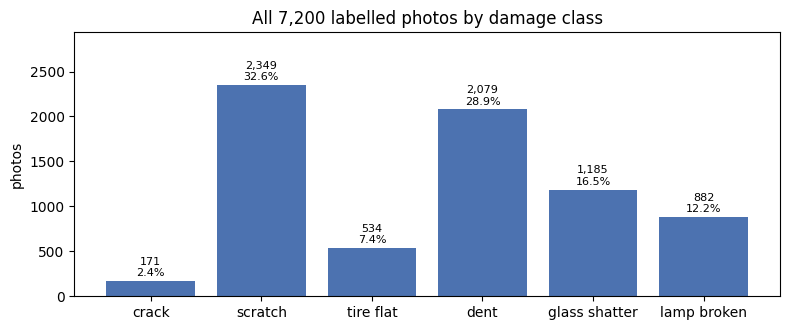

crack: 2.4% of the photos.  scratch and dent together: 61.5%.


In [4]:
counts = df["label"].value_counts().reindex(LABELS)
distribution = pd.DataFrame({"label id": range(len(LABELS)), "photos": counts,
                             "share": (counts / len(df)).map("{:.1%}".format)}, index=LABELS)
display(distribution)

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(LABELS, counts, color="#4C72B0")
for bar, value in zip(bars, counts):
    ax.annotate(f"{value:,}\n{value / len(df):.1%}", (bar.get_x() + bar.get_width() / 2, value),
                ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")
ax.set_ylim(0, counts.max() * 1.25)
ax.set_ylabel("photos")
ax.set_title(f"All {len(df):,} labelled photos by damage class")
fig.tight_layout()
plt.show()

print(f"crack: {counts['crack'] / len(df):.1%} of the photos.  "
      f"scratch and dent together: {(counts['scratch'] + counts['dent']) / len(df):.1%}.")

Scratch and dent together are 61.5% of all photos; crack is 2.4%. A model that never once says "crack" loses at most 2.4 points of accuracy. That is why section 6 reports three metrics side by side:

- **accuracy** — the share of photos classified correctly, dominated by the two large classes;
- **weighted F1** — the F1 score of each class, averaged with the class sizes as weights; the article's second metric, and close to accuracy on data like these;
- **macro F1** — the plain average of the six class F1 scores, in which crack counts as much as scratch. It is the metric that notices a neglected small class.

### 2.3 Twelve photos to look at

Numbers alone hide what the photos are like. The twelve below — two per class — are the gallery of this notebook, and the only photos of the data set it shows. None of them lies among the first 1,500 rows of `train.csv`, which hold the fine-tune's training, validation and test photos (section 3), and none is a near-copy of one of those 1,500 either. Each was compared with all 1,500, as it is and mirrored, and kept only if its 16 × 16 grey fingerprint differs from every one of theirs in at least 40 of 256 bits and the correlation of the two thumbnails stays below 0.7 — the method of section 6.9. Each was then screened by hand, and a photo showing a legible number plate, a face or a brand badge was rejected. The file `data/gallery.csv` records the screen values and a screening note for each photo. They are shown at most 256 pixels on the long side.

12 photos ready after 3.6 seconds.


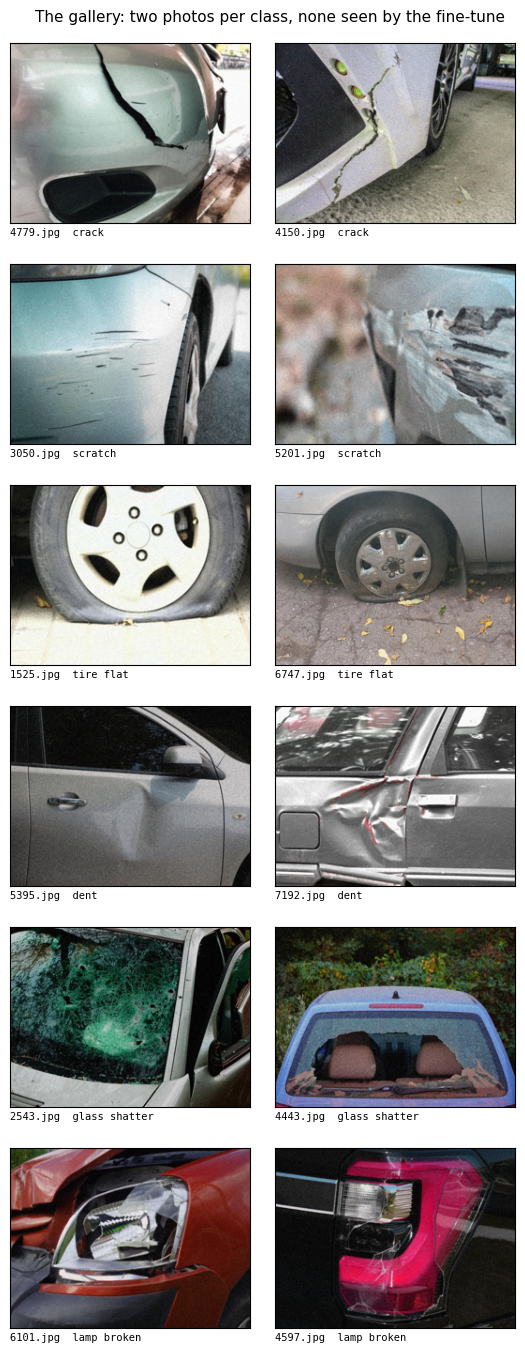

,label,size (pixels),file size (KB),max correlation,min distance (bits)
filename,,,,,
4779.jpg,crack,831 x 623,54,0.588,73
4150.jpg,crack,849 x 636,91,0.510,74
3050.jpg,scratch,1209 x 906,145,0.598,53
5201.jpg,scratch,1146 x 859,113,0.366,84
1525.jpg,tire flat,1344 x 1008,111,0.570,62
6747.jpg,tire flat,1316 x 987,195,0.583,46
5395.jpg,dent,887 x 665,100,0.618,48
7192.jpg,dent,1217 x 912,206,0.438,83
2543.jpg,glass shatter,833 x 624,126,0.547,82


[PASS] Recorded answers for the twelve photos: data/gallery_predictions_2026.csv (16 columns), used only where a model is not available.


In [5]:
GALLERY = pd.DataFrame(
    [
        ("4779.jpg", "crack"), ("4150.jpg", "crack"),
        ("3050.jpg", "scratch"), ("5201.jpg", "scratch"),
        ("1525.jpg", "tire flat"), ("6747.jpg", "tire flat"),
        ("5395.jpg", "dent"), ("7192.jpg", "dent"),
        ("2543.jpg", "glass shatter"), ("4443.jpg", "glass shatter"),
        ("6101.jpg", "lamp broken"), ("4597.jpg", "lamp broken"),
    ],
    columns=["filename", "label"],
)
# The labels above are those of train.csv, photo for photo.
assert (GALLERY["label"].to_numpy() == df.set_index("filename").loc[GALLERY["filename"], "label"].to_numpy()).all()

started = time.perf_counter()
paths = kaggle_files([f"train/train/images/{name}" for name in GALLERY["filename"]])
GALLERY_PATHS = dict(zip(GALLERY["filename"], paths))
print(f"{len(paths)} photos ready after {time.perf_counter() - started:.1f} seconds.")

THUMBS, sizes = {}, []
for name, path in GALLERY_PATHS.items():
    with Image.open(path) as image:
        sizes.append((image.width, image.height, path.stat().st_size))
        thumb = image.convert("RGB")
    thumb.thumbnail((256, 256))  # the only form in which a photo of the data set is ever displayed
    THUMBS[name] = thumb
GALLERY["size (pixels)"] = [f"{w} x {h}" for w, h, _ in sizes]
GALLERY["file size (KB)"] = [round(b / 1024) for _, _, b in sizes]

# The content screen against the first 1,500 photos, run once for this notebook (section 6.9 explains the method).
screen_path = load_data_file("gallery.csv")
GALLERY_SCREEN = pd.read_csv(screen_path).set_index("filename") if screen_path is not None else None
if GALLERY_SCREEN is not None:
    GALLERY["max correlation"] = GALLERY_SCREEN.loc[GALLERY["filename"], "max_corr"].to_numpy()
    GALLERY["min distance (bits)"] = GALLERY_SCREEN.loc[GALLERY["filename"], "min_hamming"].to_numpy()


def show_photos(names: list[str], captions: list[list[tuple[str, str]]], ncols: int, title: str | None = None,
                width: float = 2.4) -> None:
    """Photos in a grid, each drawn at most `width` inches wide at 100 dpi (240 pixels), so never larger
    than its 256-pixel thumbnail. Each caption is a list of (text, colour) lines below the photo."""
    lines = max(len(c) for c in captions)
    height = width * 0.75
    cell_w, cell_h = width + 0.25, height + 0.16 * lines + 0.25
    nrows = -(-len(names) // ncols)
    top = 0.45 if title else 0.1
    fig_w, fig_h = ncols * cell_w + 0.1, nrows * cell_h + top
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=100)
    for i, (name, caption) in enumerate(zip(names, captions)):
        row, col = divmod(i, ncols)
        left = 0.1 + col * cell_w
        bottom = fig_h - top - row * cell_h - height
        ax = fig.add_axes([left / fig_w, bottom / fig_h, width / fig_w, height / fig_h])
        ax.imshow(THUMBS[name])
        ax.set_xticks([])
        ax.set_yticks([])
        for k, (text, colour) in enumerate(caption):
            ax.text(0, -0.03 - k * 0.16 / height, text, transform=ax.transAxes, va="top", ha="left",
                    family="monospace", fontsize=7.5, color=colour)
    if title:
        fig.suptitle(title, y=1 - 0.12 / fig_h, va="top", fontsize=11)
    plt.show()


show_photos(
    GALLERY["filename"].tolist(),
    [[(f"{row.filename}  {row.label}", "black")] for row in GALLERY.itertuples()],
    ncols=2,
    title="The gallery: two photos per class, none seen by the fine-tune",
)
display(GALLERY.set_index("filename"))

# The answers recorded for these twelve photos in the run saved here. They are used only where a model
# is not available to your key.
GALLERY_RECORDED = None


recorded_path = load_data_file("gallery_predictions_2026.csv")
if recorded_path is not None:
    GALLERY_RECORDED = pd.read_csv(recorded_path).set_index("filename")
    if list(GALLERY_RECORDED.index) != list(GALLERY["filename"]):
        print("[ATTENTION] data/gallery_predictions_2026.csv belongs to another set of photos and is not used.")
        GALLERY_RECORDED = None
    else:
        print(f"[PASS] Recorded answers for the twelve photos: data/gallery_predictions_2026.csv "
              f"({GALLERY_RECORDED.shape[1]} columns), used only where a model is not available.")

What to notice, before any model has spoken:

- **Grain everywhere.** Every photo carries visible noise, as if grain had been added on purpose, and several have odd colour casts — the green windscreen of 2543.jpg, the violet rear window of 4443.jpg, the magenta tail lamp of 4597.jpg. These are not the clean photos of a car dealer's website.
- **Close crops.** Some photos show a single part and nothing else (5201.jpg, 1525.jpg, 4597.jpg): the damage is clear, but where on the car it is, is not.
- **More than one damage.** 6101.jpg is labelled lamp broken, yet the bonnet above the lamp is crumpled too; in the dented door of 7192.jpg the paint has split down to the primer. The data set allows one label per photo, and whoever labelled it had to choose.
- **Neighbouring classes.** A crack in a painted bumper (4150.jpg) runs in lines much like a scratch, and a dent with torn paint is partly a scratch. The six classes are less separate than their names suggest.

Some photos in the data set are black and white; none of these twelve happens to be.

---

## 3 The split: which photos the fine-tune has seen

### Why it matters for actuaries

A model has to be judged on data it has never seen, just as a pricing model is validated out of sample. A fine-tuned model has seen its training photos many times over, and scoring it on them would measure its memory, not its eyesight. So before comparing anything we rebuild exactly the split the fine-tune was trained on, and check that the files we score it on are ones it never saw — and, in section 6.9, whether their content is new to it as well.

### 3.1 Rebuilding the split

The fine-tune was trained on the **first 1,500 rows** of `train.csv` (the photos `1.jpg` to `1500.jpg`), split 60/20/20 into training, validation and test sets with two stratified calls of `train_test_split` and `random_state=42` — the split of the fine-tune's training run, and of the research notebook's saved predictions of March 2025 that section 6 evaluates: first 20% of the 1,500 go to the test set, then 25% of the remaining 1,200 to the validation set.

,training,validation,test,"first 1,500"
label,,,,
crack,21,7,7,35
scratch,313,104,104,521
tire flat,65,22,22,109
dent,238,79,80,397
glass shatter,151,51,50,252
lamp broken,112,37,37,186
total,900,300,300,1500


Class shares per subset:


,training,validation,test,"first 1,500","all 7,200"
label,,,,,
crack,2.3%,2.3%,2.3%,2.3%,2.4%
scratch,34.8%,34.7%,34.7%,34.7%,32.6%
tire flat,7.2%,7.3%,7.3%,7.3%,7.4%
dent,26.4%,26.3%,26.7%,26.5%,28.9%
glass shatter,16.8%,17.0%,16.7%,16.8%,16.5%
lamp broken,12.4%,12.3%,12.3%,12.4%,12.2%


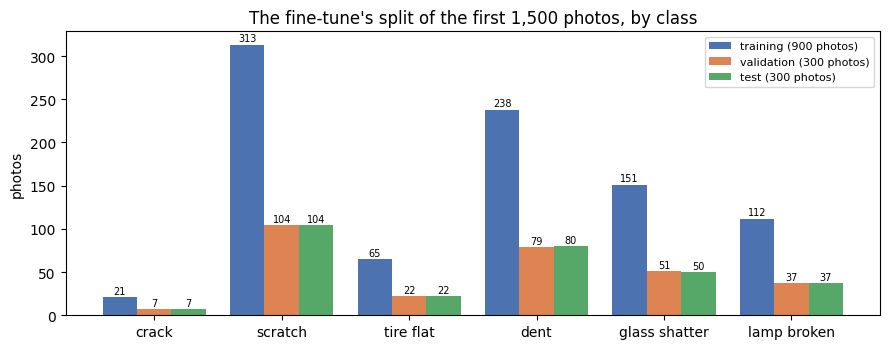

In [6]:
FIRST = df.head(1500).reset_index(drop=True)  # the photos 1.jpg to 1500.jpg
train_val, test = train_test_split(FIRST, test_size=0.2, stratify=FIRST["label_id"], random_state=SEED)
train, val = train_test_split(train_val, test_size=0.25, stratify=train_val["label_id"], random_state=SEED)
SUBSETS = {"training": train, "validation": val, "test": test}

split_counts = pd.DataFrame({name: part["label"].value_counts().reindex(LABELS) for name, part in SUBSETS.items()})
split_counts["first 1,500"] = FIRST["label"].value_counts().reindex(LABELS)
split_counts.loc["total"] = split_counts.sum()
shares = split_counts.iloc[:-1] / split_counts.iloc[-1]
shares["all 7,200"] = counts / len(df)
display(split_counts)
print("Class shares per subset:")
display(shares.map("{:.1%}".format))

x = np.arange(len(LABELS))
fig, ax = plt.subplots(figsize=(9, 3.6))
for offset, (name, colour) in zip([-0.27, 0, 0.27], zip(SUBSETS, ["#4C72B0", "#DD8452", "#55A868"])):
    values = split_counts.loc[LABELS, name]
    bars = ax.bar(x + offset, values, width=0.27, color=colour, label=f"{name} ({len(SUBSETS[name])} photos)")
    ax.bar_label(bars, fontsize=7, padding=1)
ax.set_xticks(x, LABELS)
ax.set_ylabel("photos")
ax.set_title("The fine-tune's split of the first 1,500 photos, by class")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Stratification keeps every class at almost the same share in all three subsets, and the first 1,500 rows are close to the shares of all 7,200 photos. It matters most for the small classes: the test set holds only seven cracks, so a single crack photo more or less classified correctly moves crack recall by 14 points. Keep that in mind whenever a per-class number in section 6 looks dramatic.

### 3.2 Test-set hygiene, checked

Four checks, each of which must pass before the numbers of section 6 and the gallery can be trusted. Two compare file names, one reads the content screen of the gallery from `data/gallery.csv`, and the last compares our rebuilt test set with the file of recorded predictions that section 6 evaluates: same files, same order, same labels. Whether a test photo has a near-copy among the training photos under another file name is a question of content, which section 6.9 answers.

In [7]:
PRED_PATH = load_data_file("predictions_test300.csv")
PRED = pd.read_csv(PRED_PATH) if PRED_PATH is not None else None

checks = {
    "no file is in two of the three subsets (training, validation, test)":
        set(train["filename"]).isdisjoint(val["filename"]) and set(train_val["filename"]).isdisjoint(test["filename"]),
    "none of the 12 gallery files is among the first 1,500":
        not GALLERY["filename"].isin(FIRST["filename"]).any(),
}
if GALLERY_SCREEN is not None:
    screen = GALLERY_SCREEN.loc[GALLERY["filename"]]
    checks[f"no gallery photo is a near-copy of any of the first 1,500 (correlation at most "
           f"{screen['max_corr'].max():.2f}, at least {screen['min_hamming'].min()} of 256 bits apart)"] = bool(
        (screen["max_corr"] < 0.7).all() and (screen["min_hamming"] >= 40).all())
if PRED is not None:
    checks["the test files equal data/predictions_test300.csv - same files, same order, same labels"] = (
        list(test["filename"]) == list(PRED["filename"]) and list(test["label"]) == list(PRED["label"])
    )
for text, passed in checks.items():
    print(("[PASS]      " if passed else "[ATTENTION] ") + text)
if PRED is None:
    print("[ATTENTION] data/predictions_test300.csv is not available, so section 6 cannot run.")
assert all(checks.values()), "the split does not match - do not trust section 6"

[PASS]      no file is in two of the three subsets (training, validation, test)
[PASS]      none of the 12 gallery files is among the first 1,500
[PASS]      no gallery photo is a near-copy of any of the first 1,500 (correlation at most 0.63, at least 46 of 256 bits apart)
[PASS]      the test files equal data/predictions_test300.csv - same files, same order, same labels


**Why this matters.** The fine-tune learned from the 900 training photos and was tuned on the 300 validation photos, and none of the 300 test files is among those 1,200 training and validation files. That is what makes its test score an estimate of how it would do on the next claim photo. Scored on photos it had seen, the same model would look better than it is — it may recall a label rather than read the photo — and the comparison with a zero-shot model, which has seen none of them, would be unfair. A check on file names is necessary but not sufficient: the same photo can sit in a data set twice under two names, re-coloured, cropped or mirrored. Section 6.9 screens the 300 test photos for such near-copies and reports every metric with and without them. The same discipline applies to any model you fine-tune yourself: fix the split before training, keep the test photos — and their near-copies — out of every training and tuning step, and check that the photos you score on are the ones you set aside.

---

## 4 One photo, one call

### Why it matters for actuaries

Every result in this notebook comes from the same small request, repeated: a system prompt, one photo and a schema. Seeing that request in full — what the model receives, what comes back, what it costs — takes the mystery out of "a vision model looked at the claim", and shows where the price of a photo comes from.

### 4.1 The article's system prompt

The prompt is the research notebook's, word for word. It lists the six classes, asks the model to inspect the photo, and insists on exactly one class name as the answer.

In [8]:
SYSTEM_PROMPT = """
You will classify images of cars with visible damages into one of six specific classes.
Your task is to examine the image provided, identify the type of damage, and return the correct damage type as one of the predefined classes.
The six damage classes are as follows:

1. crack
2. scratch
3. tire flat
4. dent
5. glass shatter
6. lamp broken

# Steps

1. **Analyze the Image:**
   - Carefully inspect the image provided, focusing on visible damage to determine its type.
   - Pay attention to details such as patterns, locations, and characteristics of the damage to accurately classify it.

2. **Identify the Correct Class:**
   - Match the observed damage to one of the six predefined classes listed above.
   - Avoid ambiguous classifications and ensure the answer aligns precisely with the provided options.

3. **Output the Classification:**
   - Provide your answer in a concise format with **only the name of the damage class** (e.g., "scratch").
   - Do not add any additional text, reasoning, or explanations. The response must be exactly one of the six class names.

# Notes
- If multiple damage types appear equally prominent in the image, select the one that seems most severe or predominant.
- Ensure every response falls strictly within the six defined classes. Avoid assumptions or interpretations beyond the scope of these categories.

# Example Format
For an input image with a visible scratch:
- Correct Output: "scratch"

For an input image showing a shattered glass window:
- Correct Output: "glass shatter"

Adhere to this strict output format and guidelines in every classification.
"""

print(f"System prompt: {len(SYSTEM_PROMPT):,} characters, {len(SYSTEM_PROMPT.split())} words.")

System prompt: 1,607 characters, 259 words.


### 4.2 The schema

The prompt asks for one of six names; the schema makes sure of it. This is the research notebook's Pydantic class: one field, `prediction`, whose `Literal` type admits exactly the six class names and nothing else — not "Scratch", not "scratch and dent", not "I cannot tell".

The model never sees the Python class. What travels with the request is the JSON schema Pydantic derives from it, below. The `openai` package sends it in strict mode, adding `"additionalProperties": false`, and the provider then constrains the model's output to fit.

In [9]:
class DamageType(BaseModel):
    prediction: Literal["crack", "scratch", "tire flat", "dent", "glass shatter", "lamp broken"]


print(json.dumps(DamageType.model_json_schema(), indent=2))

{
  "properties": {
    "prediction": {
      "enum": [
        "crack",
        "scratch",
        "tire flat",
        "dent",
        "glass shatter",
        "lamp broken"
      ],
      "title": "Prediction",
      "type": "string"
    }
  },
  "required": [
    "prediction"
  ],
  "title": "DamageType",
  "type": "object"
}


### 4.3 From photo to text

An API request is text, so the photo has to become text too. **Base64** writes any sequence of bytes with 64 printable characters: every 3 bytes become 4 characters, so the text is a third longer than the file. A short header in front — `data:image/jpeg;base64,` — turns it into a **data URL**, which the API accepts wherever it accepts the address of an image. We use the photo 5395.jpg, a dent from the gallery, and send the original file, exactly as the research notebook did, leaving any shrinking to the API.

In [10]:
PHOTO = "5395.jpg"
photo_path = GALLERY_PATHS[PHOTO]
photo_bytes = photo_path.read_bytes()
encoded = base64.b64encode(photo_bytes).decode("ascii")
photo_url = "data:image/jpeg;base64," + encoded

with Image.open(photo_path) as image:
    print(f"Photo            : {PHOTO}, labelled '{GALLERY.set_index('filename').loc[PHOTO, 'label']}', "
          f"{image.width} x {image.height} pixels")
print(f"JPEG file        : {len(photo_bytes):,} bytes")
print(f"Base64 text      : {len(encoded):,} characters ({len(encoded) / len(photo_bytes):.3f} characters per byte)")
print(f"First characters : {encoded[:60]}...")
print(f"Data URL starts  : {photo_url[:40]}...")
print(f"First bytes      : {photo_bytes[:3].hex(' ')}  - every JPEG file starts with ff d8 ff, which base64 writes as '/9j/'")

Photo            : 5395.jpg, labelled 'dent', 887 x 665 pixels
JPEG file        : 102,015 bytes
Base64 text      : 136,020 characters (1.333 characters per byte)
First characters : /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsL...
Data URL starts  : data:image/jpeg;base64,/9j/4AAQSkZJRgABA...
First bytes      : ff d8 ff  - every JPEG file starts with ff d8 ff, which base64 writes as '/9j/'


### 4.4 The request, and one call to the fine-tune

`ask_about_photo()` is the whole method: the system prompt goes in as `instructions`, the photo as an `input_image` with `"detail": "low"` (as in the article), and the schema as `text_format` — the `client.responses.parse` call of `02_llm_techniques`, now with a photo. It records the tokens and the cost of every call in the ledger, returns the time with each answer, retries on rate limits, and never lets a failed call stop the notebook: a failure is recorded as a failure, never as an answer.

Here is the request as it is sent, with the long strings cut short, followed by one call to the fine-tuned model.

In [11]:
def usage_counts(usage) -> tuple[int, int, int, int, int]:
    # (input, cached input, cache-write, output, reasoning) tokens from a Responses API usage object.
    # cache_write_tokens is a typed field in openai 3.x and an untyped extra one in 2.x: getattr reads both, 0 if absent.
    input_details = getattr(usage, "input_tokens_details", None)
    output_details = getattr(usage, "output_tokens_details", None)
    cached = (getattr(input_details, "cached_tokens", 0) or 0) if input_details else 0
    cache_write = (getattr(input_details, "cache_write_tokens", 0) or 0) if input_details else 0
    reasoning = (getattr(output_details, "reasoning_tokens", 0) or 0) if output_details else 0
    return usage.input_tokens, cached, cache_write, usage.output_tokens, reasoning


def data_url(path: Path) -> str:
    # A photo as text: its bytes in base64, behind a header that names the file type.
    mime = "image/png" if path.suffix.lower() == ".png" else "image/jpeg"
    return f"data:{mime};base64," + base64.b64encode(path.read_bytes()).decode("ascii")


def ask_about_photo(path: Path, model: str, instructions: str = SYSTEM_PROMPT, schema=DamageType,
                    purpose: str = "photo", detail: str = "low") -> dict:
    """One photo, one call: the prompt as instructions, the photo as input, the schema as text_format."""
    options = SAMPLING_OPTIONS.get(model, {})
    record = {"filename": path.name, "model": model, "parsed": None, "raw_json": None, "error": None,
              "answered_by": None, "input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0,
              "cost_usd": 0.0, "seconds": None}
    if client is None or NO_CREDIT["flag"]:
        record["error"] = "no API key" if client is None else "no credit left on this key"
        return record

    def call():
        started = time.perf_counter()
        response = client.responses.parse(
            model=model,
            instructions=instructions,
            input=[{"role": "user", "content": [{"type": "input_image", "image_url": data_url(path), "detail": detail}]}],
            text_format=schema,
            **options,
        )
        return response, time.perf_counter() - started  # the time of the successful attempt only

    try:
        response, seconds = with_retry(call)
        tokens_in, cached, cache_write, tokens_out, reasoning = usage_counts(response.usage)
        cost = log_usage(model, purpose, tokens_in, cached, tokens_out, cache_write_tokens=cache_write)
        record.update(parsed=response.output_parsed, raw_json=response.output_text, answered_by=response.model,
                      input_tokens=tokens_in, output_tokens=tokens_out, reasoning_tokens=reasoning,
                      seconds=round(seconds, 2), cost_usd=cost)
        if response.output_parsed is None:
            record["error"] = "no parsed answer - the model may have refused"
    except Exception as exc:  # recorded as a failure, never as an answer, and never allowed to stop the notebook
        record["error"] = short_error(exc)
    return record


def recorded_answer(name: str, column: str):
    # The answer recorded in the run saved here for one gallery photo, or None.
    if GALLERY_RECORDED is None or column not in GALLERY_RECORDED.columns:
        return None
    value = GALLERY_RECORDED.loc[name, column]
    return None if pd.isna(value) else value


single_model = MODEL_FINETUNED if can_call(MODEL_FINETUNED) else MODEL_BASE if can_call(MODEL_BASE) else None
request_as_sent = {
    "model": single_model or MODEL_FINETUNED,
    "instructions": SYSTEM_PROMPT.strip().splitlines()[0] + " ...",
    "input": [{"role": "user", "content": [
        {"type": "input_image", "image_url": photo_url[:40] + f"... ({len(photo_url):,} characters)", "detail": "low"}]}],
    "text_format": "DamageType, sent as the strict JSON schema of section 4.2",
    **SAMPLING_OPTIONS.get(single_model or MODEL_FINETUNED, {}),
}
print(json.dumps(request_as_sent, indent=2))
print()

if single_model is None:
    print("[ATTENTION] Nothing was sent: no key, or neither GPT-4o model is visible to it.")
    print(f"            In the run saved here, the fine-tune answered: {recorded_answer(PHOTO, 'gpt4o_finetuned')}")
else:
    if single_model != MODEL_FINETUNED:
        print("[ATTENTION] The fine-tuned model is not visible to this key; the same request goes to its base model.")
    single = ask_about_photo(photo_path, single_model, purpose="one photo, one call")
    print(f"Model asked      : {single['model']}")
    print(f"Answered by      : {single['answered_by']}")
    print(f"Error            : {single['error']}")
    print(f"Raw JSON         : {single['raw_json']}")
    print(f"Parsed           : {single['parsed']!r}")
    print(f"True label       : {GALLERY.set_index('filename').loc[PHOTO, 'label']}")
    print(f"Tokens           : {single['input_tokens']:,} in, {single['output_tokens']:,} out")
    print(f"Cost             : USD {single['cost_usd']:.5f}, or USD {single['cost_usd'] * 1000:.2f} per 1,000 such photos")
    print(f"Time             : {single['seconds']} seconds")

{
  "model": "ft:gpt-4o-2024-08-06:personal::B5swMoBf",
  "instructions": "You will classify images of cars with visible damages into one of six specific classes. ...",
  "input": [
    {
      "role": "user",
      "content": [
        {
          "type": "input_image",
          "image_url": "data:image/jpeg;base64,/9j/4AAQSkZJRgABA... (136,043 characters)",
          "detail": "low"
        }
      ]
    }
  ],
  "text_format": "DamageType, sent as the strict JSON schema of section 4.2",
  "temperature": 0
}

Model asked      : ft:gpt-4o-2024-08-06:personal::B5swMoBf
Answered by      : ft:gpt-4o-2024-08-06:personal::B5swMoBf
Error            : None
Raw JSON         : {"prediction":"dent"}
Parsed           : DamageType(prediction='dent')
True label       : dent
Tokens           : 482 in, 6 out
Cost             : USD 0.00190, or USD 1.90 per 1,000 such photos
Time             : 1.61 seconds


The answer is `{"prediction":"dent"}`: exactly the one field the schema allows, holding one of the six permitted values — and here the right one. Pydantic has turned it into a Python object, so `single["parsed"].prediction` is simply the string `"dent"`.

Now the bill: 482 input tokens, 6 output tokens, USD 0.0019. The output is tiny, as it should be — a class name and a little JSON punctuation. The input is the system prompt, the schema and the photo. At this price, 1,000 photos cost USD 1.90 on the fine-tune.

### 4.5 What a photo costs in tokens

How many of those input tokens are the photo? The Responses API has an endpoint that counts the input tokens of a request without running the model. We count a request whose user message holds a single character of text, and the same request with the photo added: the difference is the photo. We do it at `"detail": "low"`, the article's setting, and at `"high"`, for each of the four classification models.

In [12]:
def photo_tokens(model: str, detail: str) -> int:
    # Input tokens the photo adds to a request: the count with the photo minus the count without it.
    def count(content: list) -> int:
        return client.responses.input_tokens.count(
            model=model, instructions=SYSTEM_PROMPT, input=[{"role": "user", "content": content}]
        ).input_tokens

    placeholder = {"type": "input_text", "text": "x"}
    photo = {"type": "input_image", "image_url": photo_url, "detail": detail}
    return count([placeholder, photo]) - count([placeholder])


rows = []
for model in [MODEL_BASE, MODEL_FINETUNED, MODEL_NOW, MODEL_BENCH]:
    if not AVAILABLE[model]:
        print(f"[ATTENTION] {model} is not available to this key; its row is missing.")
        continue
    try:
        low, high = photo_tokens(model, "low"), photo_tokens(model, "high")
    except Exception as exc:
        print(f"[ATTENTION] {model}: the token count failed ({short_error(exc)}).")
        continue
    rows.append({
        "model": MODEL_LABELS[model],
        "photo tokens, low": low,
        "photo tokens, high": high,
        "USD per 1,000 photos, low": round(low * PRICES_USD_PER_MTOK[model][0] / 1000, 3),
        "USD per 1,000 photos, high": round(high * PRICES_USD_PER_MTOK[model][0] / 1000, 3),
    })
if rows:
    print(f"{PHOTO}: the input tokens of the photo alone, and their price at each model's input rate:")
    display(pd.DataFrame(rows).set_index("model"))
else:
    print("[ATTENTION] No token counts without a key. For GPT-4o, a photo at 'low' costs a flat 85 tokens.")

5395.jpg: the input tokens of the photo alone, and their price at each model's input rate:


,"photo tokens, low","photo tokens, high","USD per 1,000 photos, low","USD per 1,000 photos, high"
model,,,,
GPT-4o zero-shot,85,765,0.212,1.913
GPT-4o fine-tuned,85,765,0.319,2.869
GPT-6 Luna,231,706,0.023,0.071
GPT-5.4 mini,706,706,0.529,0.529


Four models, three pricing logics:

- **GPT-4o and its fine-tune** charge a flat 85 tokens for a photo at `"low"`, whatever its size: the photo is shrunk to fit 512 × 512 pixels and read as a single tile. At `"high"` it is cut into tiles of 512 pixels, each costing 170 tokens on top of the base 85 — here four tiles, 765 tokens, nine times as much. So of the fine-tune's 482 input tokens in 4.4, the photo accounts for 85; the rest is the system prompt and the schema.
- **GPT-6 Luna** charges 231 tokens at `"low"` and 706 at `"high"`: more than GPT-4o at `"low"`, fewer at `"high"`, and at its price the photo costs USD 0.023 per 1,000 at `"low"`.
- **GPT-5.4 mini** charges 706 tokens at both settings: for this model and this photo, `"low"` changes nothing. How many tokens it charges grows with the size of the photo; over the 300 test photos of section 6 its requests averaged about 1,500 input tokens.

For a cost estimate, the price per token is only half the story. The same photo at the same setting is 85 tokens on one model and 706 on another.

---

## 5 Twelve photos, three models, live

### Why it matters for actuaries

One call shows the mechanics; twelve show behaviour. Here the same twelve photos go to three models: GPT-4o as it comes, the same GPT-4o after the article's fine-tuning, and GPT-6 Luna, the newest and cheapest general model. Same prompt, same schema, same photos — any difference is the model.

The 36 calls run in parallel, eight at a time, because none depends on another. A model your key cannot see is replaced by the answers recorded in the run saved here, marked with an asterisk.

In [13]:
LIVE_MODELS = {  # label -> (model, column of the recorded answers)
    "GPT-4o zero-shot": (MODEL_BASE, "gpt4o_zeroshot"),
    "GPT-4o fine-tuned": (MODEL_FINETUNED, "gpt4o_finetuned"),
    "GPT-6 Luna": (MODEL_NOW, "gpt6_luna"),
}


def gallery_job(job: tuple[str, str]) -> dict:
    label, name = job
    model, column = LIVE_MODELS[label]
    row = {"model": label, "filename": name, "prediction": None, "source": None, "error": None,
           "input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0, "cost_usd": 0.0, "seconds": None}
    if can_call(model):
        record = ask_about_photo(GALLERY_PATHS[name], model, purpose="twelve photos, live")
        row.update({k: record[k] for k in ["error", "input_tokens", "output_tokens", "reasoning_tokens", "cost_usd", "seconds"]})
        if record["error"] is None:
            row.update(prediction=record["parsed"].prediction, source="live")
        elif not NO_CREDIT["flag"]:
            row["source"] = "failed"
    if row["source"] is None:  # the model is not available to this key, or the key has no credit left
        row["prediction"] = recorded_answer(name, column)
        row["source"] = "recorded" if row["prediction"] else "missing"
    return row


def report_failures(frame: pd.DataFrame) -> None:
    failed = frame[frame["source"] == "failed"]
    if failed.empty and (frame["source"] == "live").any():
        print("[PASS] No call failed.")
    elif not failed.empty:
        print(f"[ATTENTION] {len(failed)} call(s) failed; they are counted as failures, never as answers:")
        for row in failed.itertuples():
            print(f"            {row.model:<18} {row.filename:<9} {row.error}")
    if (frame["source"] == "recorded").any():
        print(f"[ATTENTION] {(frame['source'] == 'recorded').sum()} answers are the ones recorded in the run saved here, "
              "because a model is not available to this key.")
    if (frame["source"] == "missing").any():
        print(f"[ATTENTION] {(frame['source'] == 'missing').sum()} answers are missing: the model is not available to "
              "this key, and no recorded answer could be loaded.")
    if NO_CREDIT["flag"]:
        print("[ATTENTION] The key has no credit left (insufficient_quota): from here on, recorded answers are used.")


jobs = [(label, name) for label in LIVE_MODELS for name in GALLERY["filename"]]
started = time.perf_counter()
with ThreadPoolExecutor(max_workers=8) as pool:
    LIVE = pd.DataFrame(list(pool.map(gallery_job, jobs)))
print(f"{len(LIVE)} answers after {time.perf_counter() - started:.0f} seconds.")
report_failures(LIVE)

answers = LIVE.pivot(index="filename", columns="model", values="prediction").reindex(GALLERY["filename"])[list(LIVE_MODELS)]
LIVE_TABLE = GALLERY.set_index("filename")[["label"]].join(answers)
correct = {label: int((LIVE_TABLE[label] == LIVE_TABLE["label"]).sum()) for label in LIVE_MODELS}
display(LIVE_TABLE)
print("Correct out of 12: " + ", ".join(f"{label} {n}" for label, n in correct.items()))

36 answers after 10 seconds.
[PASS] No call failed.


,label,GPT-4o zero-shot,GPT-4o fine-tuned,GPT-6 Luna
filename,,,,
4779.jpg,crack,crack,crack,crack
4150.jpg,crack,crack,crack,crack
3050.jpg,scratch,scratch,scratch,scratch
5201.jpg,scratch,scratch,scratch,scratch
1525.jpg,tire flat,tire flat,tire flat,tire flat
6747.jpg,tire flat,tire flat,tire flat,tire flat
5395.jpg,dent,dent,dent,dent
7192.jpg,dent,dent,dent,dent
2543.jpg,glass shatter,glass shatter,glass shatter,glass shatter


Correct out of 12: GPT-4o zero-shot 12, GPT-4o fine-tuned 12, GPT-6 Luna 12


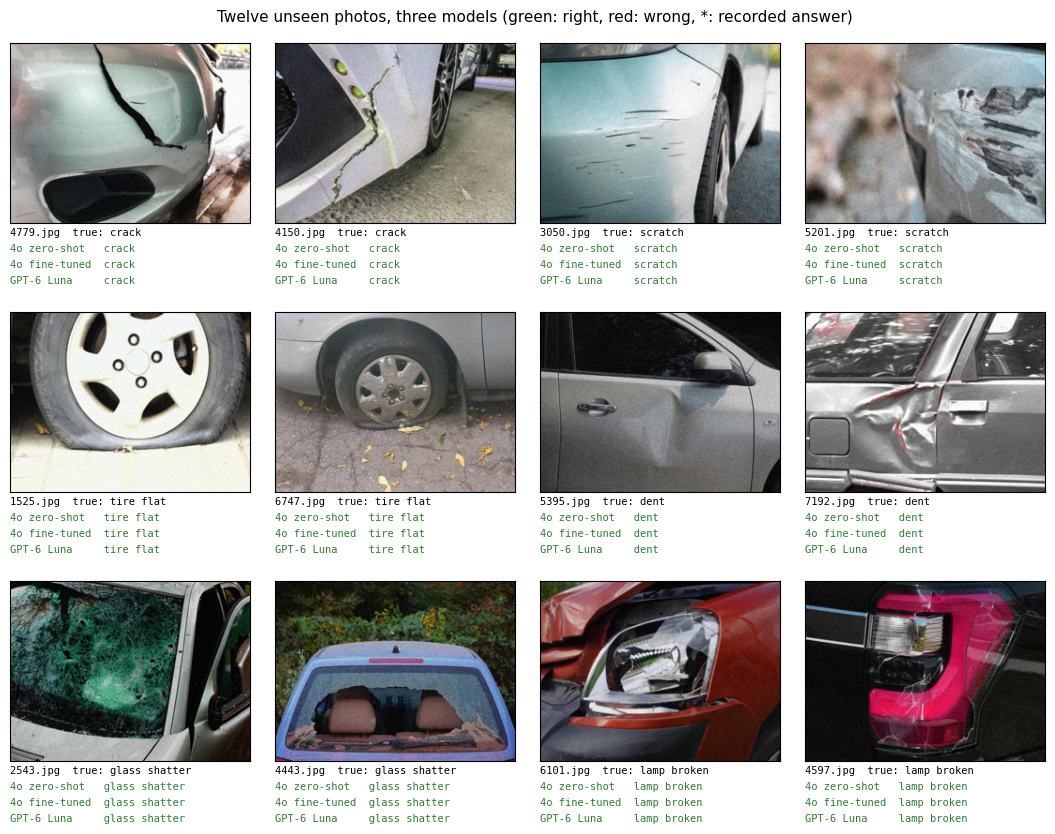

In [14]:
SHORT = {"GPT-4o zero-shot": "4o zero-shot", "GPT-4o fine-tuned": "4o fine-tuned", "GPT-6 Luna": "GPT-6 Luna"}


def verdict_line(label: str, prediction, truth: str, source: str = "live") -> tuple[str, str]:
    # One caption line: the model's answer, green if right, red if wrong, grey if missing.
    mark = "*" if source == "recorded" else ""
    if prediction is None or (isinstance(prediction, float) and np.isnan(prediction)):
        return f"{SHORT[label]:<14} (no answer)", "grey"
    return f"{SHORT[label]:<14} {prediction}{mark}", "#2E7D32" if prediction == truth else "#C62828"


source_of = LIVE.set_index(["filename", "model"])["source"]
captions = []
for row in LIVE_TABLE.itertuples():
    name, truth = row.Index, row.label
    lines = [(f"{name}  true: {truth}", "black")]
    lines += [verdict_line(label, LIVE_TABLE.loc[name, label], truth, source_of[(name, label)]) for label in LIVE_MODELS]
    captions.append(lines)
show_photos(LIVE_TABLE.index.tolist(), captions, ncols=4,
            title="Twelve unseen photos, three models (green: right, red: wrong, *: recorded answer)")

And what the twelve calls cost per model. The latencies were measured with eight calls in flight at once, so they include some queueing.

In [15]:
live_only = LIVE[LIVE["source"] == "live"]
if live_only.empty:
    print("[ATTENTION] No live calls in this session, so there is nothing to price.")
else:
    economics = live_only.groupby("model", sort=False).agg(
        calls=("cost_usd", "size"),
        input_tokens_min=("input_tokens", "min"),
        input_tokens_max=("input_tokens", "max"),
        output_tokens_mean=("output_tokens", "mean"),
        reasoning_tokens_mean=("reasoning_tokens", "mean"),
        cost_usd=("cost_usd", "sum"),
        median_seconds=("seconds", "median"),
        slowest_seconds=("seconds", "max"),
    )
    economics["usd_per_1000_photos"] = economics["cost_usd"] / economics["calls"] * 1000
    display(economics.round({"output_tokens_mean": 1, "reasoning_tokens_mean": 1, "cost_usd": 4,
                             "usd_per_1000_photos": 2, "median_seconds": 2, "slowest_seconds": 2}))

,calls,input_tokens_min,input_tokens_max,output_tokens_mean,reasoning_tokens_mean,cost_usd,median_seconds,slowest_seconds,usd_per_1000_photos
model,,,,,,,,,
GPT-4o zero-shot,12,481,481,7.0,0.0,0.0153,1.50,2.29,1.27
GPT-4o fine-tuned,12,482,482,7.0,0.0,0.0229,1.23,1.88,1.91
GPT-6 Luna,12,626,626,86.3,70.3,0.0013,1.94,3.75,0.11


On these twelve photos the three models agree completely: each gets all twelve right. That is worth understanding before it is worth celebrating:

- **The gallery is not a test.** Its photos were chosen to be shown, and they are clear examples of their classes. Twelve photos cannot rank models; section 6 does that on 300 test photos, on which every model makes dozens of mistakes.
- **Price and speed are where the models differ.** Per 1,000 photos, the fine-tune costs USD 1.91, GPT-4o USD 1.27 and GPT-6 Luna USD 0.11. The fine-tune uses the same tokens as its base model at a higher price; Luna uses more tokens — for the photo, and on average 70 reasoning tokens before it answers — at a far lower price. It is also the slowest here, with a median of 1.94 seconds against 1.23 for the fine-tune.
- **A live rerun can differ.** GPT-6 Luna manages its own sampling, and even at `temperature=0` the GPT-4o models do not guarantee identical answers.

---

## 6 Evaluation on 300 test photos

### Why it matters for actuaries

Twelve photos show behaviour; they do not measure it. A decision to put a model into a claims process needs a measurement with an honest margin of error, per class, on photos the model has never seen. This section evaluates seven sets of predictions on the 300 test photos of section 3:

| Column | Model | When | How it was called |
| --- | --- | --- | --- |
| `cnn_2025` | CNN (EfficientNet-B0), trained on the 900 training photos | March 2025 | the research notebook's saved run |
| `gpt4o_zeroshot_2025` | GPT-4o zero-shot | March 2025 | chat interface, default sampling |
| `gpt4o_finetuned_2025` | GPT-4o fine-tuned | March 2025 | chat interface, default sampling |
| `gpt4o_finetuned_2026` | GPT-4o fine-tuned | 22 September 2026 | Responses API, `temperature=0` |
| `gpt4o_zeroshot_2026` | GPT-4o zero-shot | 22 September 2026 | Responses API, `temperature=0` |
| `gpt6_luna_2026` | GPT-6 Luna | 22 September 2026 | Responses API, its own sampling and default reasoning |
| `gpt54_mini_2026` | GPT-5.4 mini | 22 September 2026 | Responses API, `temperature=0` |

The first three columns are the research notebook's saved run of March 2025 on these 300 test photos, copied unchanged. The four 2026 columns were recorded once for this notebook: 1,200 calls, all with the article's system prompt and schema and `"detail": "low"`. They are **recorded rather than live** because 1,200 calls are too many to repeat in the room; the cell below can repeat them. Section 6.9 then asks how many of the 300 test photos have a near-copy among the training and validation photos, and what the metrics look like without them.

### 6.1 Recording the 2026 predictions

Left at `False`, the flag below makes the cell read the recording's summary and change nothing. Set to `True`, it re-records all four 2026 columns: 1,200 paid calls, which cost USD 1.35 at list prices on 22 September 2026, plus the full download of the data set — 1.6 GB, and about as much again on disk while the archive is unpacked — because the 300 test photos are needed as files. Calls already made are kept in `_local/recording/<date>/`, so an interrupted recording resumes where it stopped instead of paying twice, and a recording on another day starts afresh.

In [16]:
RECORD_PREDICTIONS = False  # True: 1,200 paid calls and a 1.6 GB download - see the text above

RECORDED_COLUMNS = {  # column of predictions_test300.csv -> model
    "gpt4o_finetuned_2026": MODEL_FINETUNED,
    "gpt4o_zeroshot_2026": MODEL_BASE,
    "gpt6_luna_2026": MODEL_NOW,
    "gpt54_mini_2026": MODEL_BENCH,
}


def write_atomically(path: Path, text: str) -> None:
    # Write to a temporary name first and rename when complete, so that a half-written file never exists.
    partial = path.with_name(path.name + ".part")
    partial.write_text(text, encoding="utf-8", newline="\n")
    os.replace(partial, path)


def record_test_predictions() -> None:
    """Classify the 300 test photos with the four 2026 models and write data/predictions_test300.csv and
    data/recording_2026.json. Every answer is appended to _local/recording/ as soon as it arrives."""
    base = pd.read_csv(load_data_file("predictions_test300.csv"))
    assert list(base["filename"]) == list(test["filename"]), "the recorded file does not match the split"
    with redirect_stderr(io.StringIO()):
        images = Path(kagglehub.dataset_download(KAGGLE_HANDLE)) / "train" / "train" / "images"  # 1.6 GB
    checkpoint_dir = LOCAL_DIR / "recording" / time.strftime("%Y-%m-%d")  # a new day starts a new recording
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    summary = {"recorded_on": time.strftime("%Y-%m-%d"), "openai_python": openai.__version__,
               "prompt": "the article's SYSTEM_PROMPT, verbatim", "schema": "DamageType", "detail": "low",
               "test_photos": len(test), "prices_usd_per_mtok": {m: list(p) for m, p in PRICES_USD_PER_MTOK.items()},
               "prices_retrieved": "2026-09-22", "models": {}}
    earlier = load_data_file("recording_2026.json")
    if earlier is not None:  # keep the entries of models that are not re-recorded now
        summary["models"] = json.loads(earlier.read_text(encoding="utf-8")).get("models", {})
    for column, model in RECORDED_COLUMNS.items():
        if not can_call(model):
            print(f"[ATTENTION] {model} is not available to this key; {column} is left as it is.")
            continue
        checkpoint = checkpoint_dir / f"{column}.jsonl"
        done = {}
        if checkpoint.exists():
            for line in checkpoint.read_text(encoding="utf-8").splitlines():
                entry = json.loads(line)
                if entry["error"] is None:
                    done[entry["filename"]] = entry
        todo = [name for name in test["filename"] if name not in done]
        print(f"{column:<22} {len(done)} answers reused from today's checkpoint, {len(todo)} to record")
        started = time.perf_counter()
        with ThreadPoolExecutor(max_workers=8) as pool, checkpoint.open("a", encoding="utf-8", newline="\n") as log:
            futures = [pool.submit(ask_about_photo, images / name, model, purpose="recording") for name in todo]
            for future in as_completed(futures):
                record = future.result()
                entry = {"filename": record["filename"],
                         "prediction": record["parsed"].prediction if record["error"] is None else None,
                         **{k: record[k] for k in ["error", "answered_by", "input_tokens", "output_tokens",
                                                   "reasoning_tokens", "cost_usd", "seconds"]}}
                log.write(json.dumps(entry) + "\n")
                if entry["error"] is None:
                    done[entry["filename"]] = entry
        failed = [name for name in test["filename"] if name not in done]
        base[column] = [done[name]["prediction"] if name in done else None for name in test["filename"]]
        answers = [done[name] for name in test["filename"] if name in done]
        summary["models"][column] = {
            "model": model,
            "answered_by": sorted({a["answered_by"] for a in answers}),
            "temperature": SAMPLING_OPTIONS.get(model, {}).get("temperature", "not sent at medium effort"),
            "sampling": json.dumps(SAMPLING_OPTIONS.get(model, {})) if model in SAMPLING_OPTIONS else "the model's defaults",
            "calls_answered": len(answers),
            "calls_failed": len(failed),
            "input_tokens": int(sum(a["input_tokens"] for a in answers)),
            "output_tokens": int(sum(a["output_tokens"] for a in answers)),
            "reasoning_tokens": int(sum(a["reasoning_tokens"] for a in answers)),
            "cost_usd": round(sum(a["cost_usd"] for a in answers), 6),
            "usd_per_1000_photos": round(sum(a["cost_usd"] for a in answers) / max(len(answers), 1) * 1000, 4),
            "median_seconds": round(float(np.median([a["seconds"] for a in answers])), 3),
            "mean_seconds": round(float(np.mean([a["seconds"] for a in answers])), 3),
            "parallel_calls": 8,
        }
        print(f"{column:<22} {len(answers)} answers, {len(failed)} failed, "
              f"USD {summary['models'][column]['cost_usd']:.4f}, {time.perf_counter() - started:.0f} seconds this session")
    summary["total_cost_usd"] = round(sum(m["cost_usd"] for m in summary["models"].values()), 6)
    DATA_DIR.mkdir(exist_ok=True)
    write_atomically(DATA_DIR / "predictions_test300.csv", base.to_csv(index=False, lineterminator="\n"))
    write_atomically(DATA_DIR / "recording_2026.json", json.dumps(summary, indent=2) + "\n")
    print(f"[PASS] data/predictions_test300.csv and data/recording_2026.json written; USD {summary['total_cost_usd']:.4f}.")


if not RECORD_PREDICTIONS:
    print("Skipped: RECORD_PREDICTIONS is False. Nothing was sent, nothing was spent; the recording below is read from data/.")
elif client is None:
    print("[ATTENTION] RECORD_PREDICTIONS is True, but no key is visible: nothing was recorded.")
else:
    record_test_predictions()
    PRED = pd.read_csv(DATA_DIR / "predictions_test300.csv")

RECORDING_PATH = load_data_file("recording_2026.json")
RECORDING = json.loads(RECORDING_PATH.read_text(encoding="utf-8")) if RECORDING_PATH else None
if RECORDING:
    recording_table = pd.DataFrame(RECORDING["models"]).T[
        ["model", "temperature", "calls_answered", "calls_failed", "input_tokens", "output_tokens",
         "reasoning_tokens", "cost_usd", "usd_per_1000_photos", "median_seconds"]]
    print(f"Recorded on {RECORDING['recorded_on']} with openai {RECORDING['openai_python']}, detail '{RECORDING['detail']}', "
          f"eight calls in parallel. Total: USD {RECORDING['total_cost_usd']:.4f} at list prices.")
    display(recording_table)

Skipped: RECORD_PREDICTIONS is False. Nothing was sent, nothing was spent; the recording below is read from data/.
Recorded on 2026-09-22 with openai 2.29.0, detail 'low', eight calls in parallel. Total: USD 1.3515 at list prices.


,model,temperature,calls_answered,calls_failed,input_tokens,output_tokens,reasoning_tokens,cost_usd,usd_per_1000_photos,median_seconds
gpt4o_finetuned_2026,ft:gpt-4o-2024-08-06:personal::B5swMoBf,0,300,0,144600,2018,0,0.57252,1.9084,1.43
gpt4o_zeroshot_2026,gpt-4o-2024-08-06,0,300,0,144300,1975,0,0.3805,1.2683,1.41
gpt6_luna_2026,gpt-6-luna,not sent at medium effort,300,0,187800,36386,31677,0.036973,0.1232,2.18
gpt54_mini_2026,gpt-5.4-mini-2026-03-17,0,300,0,456960,4177,0,0.361517,1.2051,1.29


1,200 calls, not one failed, USD 1.35 at list prices: USD 0.57 for the fine-tune, USD 0.38 for GPT-4o, USD 0.36 for GPT-5.4 mini and USD 0.04 for GPT-6 Luna. Two details stand out. GPT-5.4 mini needed about 3.2 times as many input tokens per photo as GPT-4o — section 4.5 showed why — so a model that costs less than a third as much per input token ends up only about 5% cheaper per photo (USD 1.21 against USD 1.27 per 1,000). And GPT-6 Luna spent 31,677 of its 36,386 output tokens reasoning, about 106 per photo, before writing an answer of a few tokens; at its prices that still costs next to nothing.

### 6.2 The recorded predictions

One row per test photo: its file name, its label, and what each of the seven models said. A failed call would appear as an empty cell and be counted as wrong.

In [17]:
COLUMNS = {  # column -> short name used in tables and charts
    "cnn_2025": "CNN 2025",
    "gpt4o_zeroshot_2025": "GPT-4o zero-shot 2025",
    "gpt4o_finetuned_2025": "GPT-4o fine-tuned 2025",
    "gpt4o_finetuned_2026": "GPT-4o fine-tuned 2026",
    "gpt4o_zeroshot_2026": "GPT-4o zero-shot 2026",
    "gpt6_luna_2026": "GPT-6 Luna 2026",
    "gpt54_mini_2026": "GPT-5.4 mini 2026",
}
if PRED is None:
    print("[ATTENTION] data/predictions_test300.csv is not available; sections 6.2 to 6.8 have nothing to evaluate.")
    PREDS = {}
else:
    missing_columns = [c for c in COLUMNS if c not in PRED.columns]
    if missing_columns:
        print(f"[ATTENTION] Not in the file yet: {missing_columns}. Set RECORD_PREDICTIONS = True in 6.1 to record them.")
    Y = PRED["label"].to_numpy()
    PREDS = {c: PRED[c].fillna("no answer").to_numpy() for c in COLUMNS if c in PRED.columns}
    empty = {COLUMNS[c]: int(PRED[c].isna().sum()) for c in PREDS}
    print(f"{len(PRED)} test photos, {len(PREDS)} prediction columns. Empty cells (failed calls): {empty}")
    display(PRED.head(8))

300 test photos, 7 prediction columns. Empty cells (failed calls): {'CNN 2025': 0, 'GPT-4o zero-shot 2025': 0, 'GPT-4o fine-tuned 2025': 0, 'GPT-4o fine-tuned 2026': 0, 'GPT-4o zero-shot 2026': 0, 'GPT-6 Luna 2026': 0, 'GPT-5.4 mini 2026': 0}


,filename,label,cnn_2025,gpt4o_zeroshot_2025,gpt4o_finetuned_2025,gpt4o_finetuned_2026,gpt4o_zeroshot_2026,gpt6_luna_2026,gpt54_mini_2026
0,1320.jpg,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter,crack,glass shatter
1,605.jpg,lamp broken,dent,dent,dent,dent,dent,dent,dent
2,426.jpg,scratch,scratch,scratch,scratch,scratch,scratch,scratch,scratch
3,702.jpg,scratch,scratch,scratch,scratch,scratch,scratch,scratch,scratch
4,802.jpg,lamp broken,lamp broken,lamp broken,lamp broken,lamp broken,lamp broken,lamp broken,lamp broken
5,237.jpg,tire flat,tire flat,tire flat,tire flat,tire flat,tire flat,tire flat,tire flat
6,440.jpg,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter,glass shatter
7,363.jpg,dent,dent,tire flat,tire flat,tire flat,tire flat,crack,tire flat


### 6.3 Accuracy, weighted F1 and macro F1, with 95% intervals

Three hundred photos are enough to rank the models roughly, not finely. To show how roughly, every metric comes with a **95% bootstrap interval**, given to two decimals: draw 300 photos from the 300 with replacement, compute the metric, repeat 2,000 times, and keep the middle 95% of the results. All seven columns are scored on **the same 2,000 resamples** (seed 42), so that differences between two models can be bootstrapped as well — the paired intervals in the second table.

The metrics are computed from the confusion matrix in a few lines of NumPy, which makes 2,000 resamples fast; on the full test set they are checked against scikit-learn's `accuracy_score` and `f1_score`.

In [18]:
CODE = {label: i for i, label in enumerate(LABELS)}  # "no answer" becomes code 6


def to_codes(values) -> np.ndarray:
    return np.array([CODE.get(value, 6) for value in values])


def three_metrics(y: np.ndarray, p: np.ndarray) -> tuple[float, float, float]:
    """(accuracy, weighted F1, macro F1) from integer codes; a class absent from both y and p is left out of
    the macro average, as scikit-learn does with zero_division=np.nan."""
    cm = np.bincount(y * 7 + p, minlength=49).reshape(7, 7)[:6]  # rows: the six true classes
    tp = np.diag(cm[:, :6]).astype(float)
    support, predicted = cm.sum(axis=1), cm[:, :6].sum(axis=0)
    f1 = np.full(6, np.nan)
    present = (support + predicted) > 0
    f1[present] = 2 * tp[present] / (support + predicted)[present]  # F1 = 2 TP / (2 TP + FP + FN)
    return tp.sum() / len(y), float(np.nansum(f1 * support) / support.sum()), float(np.nanmean(f1))


if PREDS:
    Y_CODES = to_codes(Y)
    P_CODES = {c: to_codes(p) for c, p in PREDS.items()}
    POINT = {c: three_metrics(Y_CODES, p) for c, p in P_CODES.items()}

    # The same numbers as scikit-learn, on the full test set.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for c, p in PREDS.items():
            reference = (accuracy_score(Y, p), f1_score(Y, p, labels=LABELS, average="weighted", zero_division=np.nan),
                         f1_score(Y, p, labels=LABELS, average="macro", zero_division=np.nan))
            assert np.allclose(POINT[c], reference), c
    print("[PASS] identical to scikit-learn's accuracy_score and f1_score on the full test set")

    B = 2000
    RESAMPLES = np.random.default_rng(SEED).integers(0, len(Y), size=(B, len(Y)))  # the same resamples for every model
    BOOT = {c: np.array([three_metrics(Y_CODES[idx], p[idx]) for idx in RESAMPLES]) for c, p in P_CODES.items()}

    def interval(values: np.ndarray) -> str:
        # The 95% bootstrap interval, to two decimals: the third would suggest more precision than 300 photos give.
        low, high = np.round(np.percentile(values, [2.5, 97.5]), 2) + 0.0  # + 0.0 turns -0.00 into 0.00
        return f"[{low:.2f}, {high:.2f}]"

    rows = []
    for c in PREDS:
        acc, wf1, mf1 = POINT[c]
        rows.append({"model": COLUMNS[c], "accuracy": acc, "accuracy 95% CI": interval(BOOT[c][:, 0]),
                     "weighted F1": wf1, "weighted F1 95% CI": interval(BOOT[c][:, 1]),
                     "macro F1": mf1, "macro F1 95% CI": interval(BOOT[c][:, 2])})
    METRICS = pd.DataFrame(rows).set_index("model")
    display(METRICS.round(3))

[PASS] identical to scikit-learn's accuracy_score and f1_score on the full test set


,accuracy,accuracy 95% CI,weighted F1,weighted F1 95% CI,macro F1,macro F1 95% CI
model,,,,,,
CNN 2025,0.833,"[0.79, 0.87]",0.827,"[0.78, 0.87]",0.761,"[0.69, 0.84]"
GPT-4o zero-shot 2025,0.797,"[0.75, 0.84]",0.797,"[0.75, 0.84]",0.769,"[0.68, 0.83]"
GPT-4o fine-tuned 2025,0.870,"[0.83, 0.91]",0.869,"[0.83, 0.91]",0.890,"[0.84, 0.93]"
GPT-4o fine-tuned 2026,0.850,"[0.81, 0.89]",0.848,"[0.81, 0.89]",0.859,"[0.79, 0.91]"
GPT-4o zero-shot 2026,0.820,"[0.78, 0.86]",0.822,"[0.78, 0.86]",0.821,"[0.74, 0.88]"
GPT-6 Luna 2026,0.613,"[0.56, 0.67]",0.629,"[0.57, 0.69]",0.601,"[0.55, 0.65]"
GPT-5.4 mini 2026,0.773,"[0.72, 0.82]",0.768,"[0.71, 0.82]",0.748,"[0.66, 0.81]"


In [19]:
PAIRS = [  # (a, b): the difference a - b on the same resamples
    ("gpt4o_finetuned_2025", "gpt4o_zeroshot_2025"),
    ("gpt4o_finetuned_2025", "cnn_2025"),
    ("gpt4o_finetuned_2026", "gpt4o_zeroshot_2026"),
    ("gpt4o_finetuned_2026", "gpt6_luna_2026"),
    ("gpt4o_finetuned_2026", "gpt54_mini_2026"),
    ("gpt6_luna_2026", "gpt4o_zeroshot_2026"),
    ("gpt4o_finetuned_2026", "gpt4o_finetuned_2025"),
    ("gpt4o_zeroshot_2026", "gpt4o_zeroshot_2025"),
]


def excludes_zero(values: np.ndarray) -> bool:
    low, high = np.percentile(values, [2.5, 97.5])
    return bool(low > 0 or high < 0)

if PREDS:
    rows = []
    for a, b in PAIRS:
        if a not in BOOT or b not in BOOT:
            continue
        diff = BOOT[a] - BOOT[b]
        point = np.subtract(POINT[a], POINT[b])
        rows.append({
            "difference": f"{COLUMNS[a]} minus {COLUMNS[b]}",
            "accuracy": point[0], "accuracy 95% CI": interval(diff[:, 0]),
            "macro F1": point[2], "macro F1 95% CI": interval(diff[:, 2]),
            "accuracy interval excludes 0": excludes_zero(diff[:, 0]),
            "macro F1 interval excludes 0": excludes_zero(diff[:, 2]),
        })
    PAIRED = pd.DataFrame(rows).set_index("difference")
    display(PAIRED.assign(**{"accuracy": PAIRED["accuracy"].map("{:+.3f}".format),
                             "macro F1": PAIRED["macro F1"].map("{:+.3f}".format)}))

,accuracy,accuracy 95% CI,macro F1,macro F1 95% CI,accuracy interval excludes 0,macro F1 interval excludes 0
difference,,,,,,
GPT-4o fine-tuned 2025 minus GPT-4o zero-shot 2025,+0.073,"[0.03, 0.12]",+0.122,"[0.06, 0.22]",True,True
GPT-4o fine-tuned 2025 minus CNN 2025,+0.037,"[-0.01, 0.09]",+0.129,"[0.04, 0.21]",False,True
GPT-4o fine-tuned 2026 minus GPT-4o zero-shot 2026,+0.030,"[-0.01, 0.07]",+0.038,"[0.00, 0.08]",False,False
GPT-4o fine-tuned 2026 minus GPT-6 Luna 2026,+0.237,"[0.18, 0.29]",+0.259,"[0.17, 0.33]",True,True
GPT-4o fine-tuned 2026 minus GPT-5.4 mini 2026,+0.077,"[0.04, 0.12]",+0.111,"[0.06, 0.19]",True,True
GPT-6 Luna 2026 minus GPT-4o zero-shot 2026,-0.207,"[-0.26, -0.15]",-0.221,"[-0.29, -0.13]",True,True
GPT-4o fine-tuned 2026 minus GPT-4o fine-tuned 2025,-0.020,"[-0.05, 0.00]",-0.031,"[-0.09, 0.02]",False,False
GPT-4o zero-shot 2026 minus GPT-4o zero-shot 2025,+0.023,"[-0.01, 0.06]",+0.053,"[0.00, 0.13]",False,True


Read the first table from the top.

- **The March 2025 run** is the reference result: the research notebook's saved run on these 300 test photos. The CNN reaches 0.833 accuracy, GPT-4o zero-shot 0.797, and the fine-tuned GPT-4o 0.870 — the best of the three on all three metrics.
- **Macro F1 changes the picture for the CNN**: 0.833 accuracy but 0.761 macro F1, because it finds only one of the seven cracks (section 6.5). The fine-tune's macro F1, 0.890, is higher than its accuracy, because it finds all seven.
- **The intervals are wide**: about ±0.04 for accuracy, and wider for macro F1, which hangs on seven crack photos. In the paired table, the fine-tune's 2025 lead over zero-shot GPT-4o, +0.073, has an interval from 0.03 to 0.12 that excludes zero; its lead over the CNN, +0.037, has one that does not.
- **The 2026 re-run of the same two models lies closer together**: fine-tuned 0.850, zero-shot 0.820. The paired difference, +0.030, has an interval from −0.01 to 0.07 — on 300 photos, not distinguishable from zero.
- **GPT-6 Luna comes last** with 0.613, 0.237 below the fine-tune and 0.207 below GPT-4o zero-shot. GPT-5.4 mini, at 0.773, sits in between.

The paired intervals are computed on the same resamples for a reason: a resample full of easy photos is easy for both models, and that shared luck cancels in the difference. The last two rows of the paired table compare each GPT-4o model with itself, eighteen months apart; section 6.7 comes back to them. Section 6.9 repeats the first table without the test photos that have a near-copy among the training and validation photos — which changes the CNN's result more than any other.

### 6.4 Confusion matrices

A confusion matrix shows where the errors go: rows are the true classes, columns the predicted ones, and the diagonal holds the correct answers. The rows and columns are always in the article's label order, crack to lamp broken.

> **Tip.** Pass the labels to `confusion_matrix` explicitly, as `labels=LABELS`. Leave them out and scikit-learn sorts the labels it finds; build the tick labels from `df["label"].unique()` instead and you get them in order of first appearance — which need not match the matrix. The rows are then misnamed, and nothing warns you.

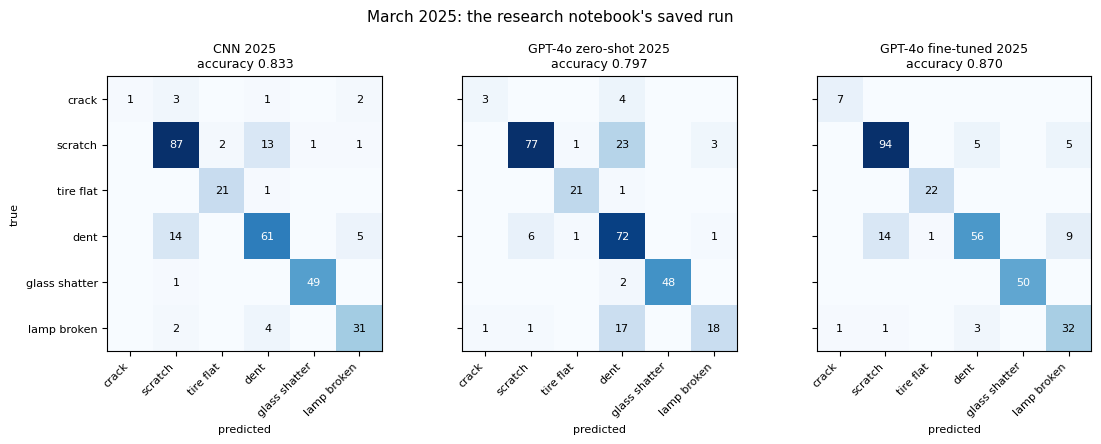

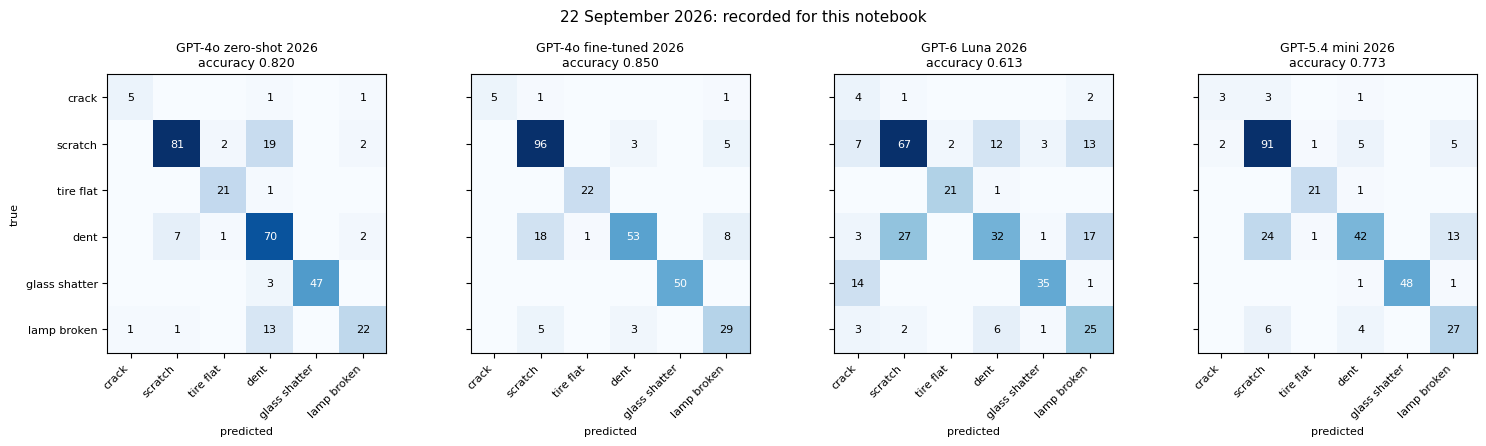

The largest confusions (true -> predicted, number of photos):
  CNN 2025                dent -> scratch 14, scratch -> dent 13, dent -> lamp broken 5, lamp broken -> dent 4
  GPT-4o zero-shot 2025   scratch -> dent 23, lamp broken -> dent 17, dent -> scratch 6, crack -> dent 4
  GPT-4o fine-tuned 2025  dent -> scratch 14, dent -> lamp broken 9, scratch -> lamp broken 5, scratch -> dent 5
  GPT-4o fine-tuned 2026  dent -> scratch 18, dent -> lamp broken 8, scratch -> lamp broken 5, lamp broken -> scratch 5
  GPT-4o zero-shot 2026   scratch -> dent 19, lamp broken -> dent 13, dent -> scratch 7, glass shatter -> dent 3
  GPT-6 Luna 2026         dent -> scratch 27, dent -> lamp broken 17, glass shatter -> crack 14, scratch -> lamp broken 13
  GPT-5.4 mini 2026       dent -> scratch 24, dent -> lamp broken 13, lamp broken -> scratch 6, scratch -> lamp broken 5


In [20]:
def plot_confusions(columns: list[str], title: str) -> None:
    columns = [c for c in columns if c in PREDS]
    if not columns:
        print("[ATTENTION] Nothing to plot.")
        return
    fig, axes = plt.subplots(1, len(columns), figsize=(3.9 * len(columns), 4.2), squeeze=False)
    for k, (ax, c) in enumerate(zip(axes[0], columns)):
        cm = confusion_matrix(Y, PREDS[c], labels=LABELS)  # rows and columns in the fixed label order
        ax.imshow(cm, cmap="Blues")
        for i in range(len(LABELS)):
            for j in range(len(LABELS)):
                if cm[i, j]:
                    ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                            color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks(range(len(LABELS)), LABELS, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(LABELS)), LABELS if k == 0 else [], fontsize=8)
        ax.set_title(f"{COLUMNS[c]}\naccuracy {POINT[c][0]:.3f}", fontsize=9)
        ax.set_xlabel("predicted", fontsize=8)
    axes[0][0].set_ylabel("true", fontsize=8)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


def largest_confusions(c: str, n: int = 4) -> str:
    cm = confusion_matrix(Y, PREDS[c], labels=LABELS)
    np.fill_diagonal(cm, 0)
    order = np.dstack(np.unravel_index(np.argsort(-cm, axis=None), cm.shape))[0][:n]
    return ", ".join(f"{LABELS[i]} -> {LABELS[j]} {cm[i, j]}" for i, j in order if cm[i, j])


if PREDS:
    plot_confusions(["cnn_2025", "gpt4o_zeroshot_2025", "gpt4o_finetuned_2025"], "March 2025: the research notebook's saved run")
    plot_confusions(["gpt4o_zeroshot_2026", "gpt4o_finetuned_2026", "gpt6_luna_2026", "gpt54_mini_2026"],
                    "22 September 2026: recorded for this notebook")
    print("The largest confusions (true -> predicted, number of photos):")
    for c in PREDS:
        print(f"  {COLUMNS[c]:<23} {largest_confusions(c)}")

Where the errors live:

- **Zero-shot GPT-4o says "dent" far too often.** In 2025, 23 scratches and 17 broken lamps became dents; the fine-tune cut these to 5 and 3.
- **The fine-tune pays for it in the dent row**: 14 dents became scratches and 9 became broken lamps.
- **The 2026 runs repeat the pattern.** Zero-shot GPT-4o still turns 19 scratches and 13 broken lamps into dents; the fine-tune turns 18 dents into scratches and 8 into broken lamps.
- **GPT-6 Luna errs in every direction**: 27 dents called scratches, 17 dents called broken lamps, 13 scratches called broken lamps, and 14 of the 50 shattered windows called cracks. The last is arguably a matter of words — a shattered window is full of cracks — but the data set's labels are the yardstick.
- **GPT-5.4 mini** shares the fine-tune's weak spot, with 24 dents called scratches and 13 called broken lamps.

### 6.5 Recall per class

Recall is the share of each true class that a model finds — the diagonal of the confusion matrix divided by the row total. The first column gives the number of test photos per class; with seven cracks, one photo moves crack recall by 14 points.

In [21]:
if PREDS:
    recall = pd.DataFrame(
        {COLUMNS[c]: np.diag(confusion_matrix(Y, p, labels=LABELS)) / pd.Series(Y).value_counts().reindex(LABELS).to_numpy()
         for c, p in PREDS.items()},
        index=LABELS,
    )
    recall.insert(0, "test photos", pd.Series(Y).value_counts().reindex(LABELS).to_numpy())
    display(recall.round(2))

,test photos,CNN 2025,GPT-4o zero-shot 2025,GPT-4o fine-tuned 2025,GPT-4o fine-tuned 2026,GPT-4o zero-shot 2026,GPT-6 Luna 2026,GPT-5.4 mini 2026
crack,7,0.14,0.43,1.00,0.71,0.71,0.57,0.43
scratch,104,0.84,0.74,0.90,0.92,0.78,0.64,0.88
tire flat,22,0.95,0.95,1.00,1.00,0.95,0.95,0.95
dent,80,0.76,0.90,0.70,0.66,0.88,0.40,0.52
glass shatter,50,0.98,0.96,1.00,1.00,0.94,0.70,0.96
lamp broken,37,0.84,0.49,0.86,0.78,0.59,0.68,0.73


Three rows carry most of the story:

- **crack** (7 photos): the CNN finds one of them (0.14), zero-shot GPT-4o three (0.43), the 2025 fine-tune all seven. With seven photos these are anecdotes, not rates.
- **dent** (80 photos): the one class where the zero-shot GPT-4o runs beat the fine-tune — 0.90 and 0.88 against 0.70 and 0.66 — because they say "dent" so readily.
- **lamp broken** (37 photos): zero-shot GPT-4o finds about half (0.49 in 2025, 0.59 in 2026), the fine-tune 0.86 and 0.78.

Glass shatter and tire flat are close to solved by the CNN and by every GPT-4o run.

### 6.6 What fine-tuning fixed, and what it broke

Accuracy nets gains against losses. On the photos of the 2025 run, compare the zero-shot and the fine-tuned GPT-4o photo by photo: **fixed** means the zero-shot model was wrong and the fine-tune right; **broken** means the reverse.

In [22]:
if {"gpt4o_zeroshot_2025", "gpt4o_finetuned_2025"} <= PREDS.keys():
    zs, ft = PREDS["gpt4o_zeroshot_2025"], PREDS["gpt4o_finetuned_2025"]
    fixed, broken = (zs != Y) & (ft == Y), (zs == Y) & (ft != Y)
    print(f"Fixed by fine-tuning : {fixed.sum():>3} photos")
    print(f"Broken by it         : {broken.sum():>3} photos")
    print(f"Net                  : {fixed.sum() - broken.sum():+d} photos = {(fixed.sum() - broken.sum()) / len(Y):+.3f} accuracy")
    print(f"Right both times     : {((zs == Y) & (ft == Y)).sum():>3};  wrong both times: {((zs != Y) & (ft != Y)).sum()}")

    by_class = pd.DataFrame({"test photos": pd.Series(Y).value_counts().reindex(LABELS),
                             "fixed": pd.Series(Y[fixed]).value_counts().reindex(LABELS, fill_value=0),
                             "broken": pd.Series(Y[broken]).value_counts().reindex(LABELS, fill_value=0)})
    display(by_class)

    how_often = pd.DataFrame({"true": pd.Series(Y).value_counts().reindex(LABELS)}
                             | {COLUMNS[c]: pd.Series(PREDS[c]).value_counts().reindex(LABELS, fill_value=0)
                                for c in ["gpt4o_zeroshot_2025", "gpt4o_finetuned_2025"]})
    print("How often each class is predicted, against how often it is true:")
    display(how_often)

    cm_zs = confusion_matrix(Y, zs, labels=LABELS)
    cm_ft = confusion_matrix(Y, ft, labels=LABELS)
    d = {label: i for i, label in enumerate(LABELS)}
    print(f"Zero-shot 2025 : scratch -> dent {cm_zs[d['scratch'], d['dent']]}, lamp broken -> dent {cm_zs[d['lamp broken'], d['dent']]}, "
          f"dent recall {cm_zs[d['dent'], d['dent']] / cm_zs[d['dent']].sum():.2f}")
    print(f"Fine-tuned 2025: scratch -> dent {cm_ft[d['scratch'], d['dent']]}, lamp broken -> dent {cm_ft[d['lamp broken'], d['dent']]}, "
          f"dent recall {cm_ft[d['dent'], d['dent']] / cm_ft[d['dent']].sum():.2f} "
          f"(dent -> scratch {cm_ft[d['dent'], d['scratch']]}, dent -> lamp broken {cm_ft[d['dent'], d['lamp broken']]})")

Fixed by fine-tuning :  40 photos
Broken by it         :  18 photos
Net                  : +22 photos = +0.073 accuracy
Right both times     : 221;  wrong both times: 21


,test photos,fixed,broken
crack,7,4,0
scratch,104,17,0
tire flat,22,1,0
dent,80,2,18
glass shatter,50,2,0
lamp broken,37,14,0


How often each class is predicted, against how often it is true:


,true,GPT-4o zero-shot 2025,GPT-4o fine-tuned 2025
crack,7,4,8
scratch,104,84,109
tire flat,22,23,23
dent,80,119,64
glass shatter,50,48,50
lamp broken,37,22,46


Zero-shot 2025 : scratch -> dent 23, lamp broken -> dent 17, dent recall 0.90
Fine-tuned 2025: scratch -> dent 5, lamp broken -> dent 3, dent recall 0.70 (dent -> scratch 14, dent -> lamp broken 9)


Fine-tuning fixed 40 photos and broke 18: a net gain of 22 photos, the +0.073 of accuracy in 6.3. The fixes are mostly scratches (17), broken lamps (14) and cracks (4); all 18 breaks are dents. The prediction counts show the mechanism. Zero-shot GPT-4o said "dent" 119 times for 80 true dents; the fine-tune says it 64 times. It has learned to stop over-calling dents, and now under-calls them: its dent recall falls from 0.90 to 0.70, with 14 dents taken for scratches and 9 for broken lamps.

Fine-tuning moved the errors and reduced them; it did not remove them. For an insurer this is a trade-off to examine rather than a better number to accept: which error costs more depends on what each class triggers downstream.

### 6.7 Run-to-run stability

The same model, the same prompt, the same 300 photos, eighteen months apart: how often does the answer change? Two things differ between the runs — the 2025 calls went through the chat interface at the default sampling temperature, the 2026 calls through the Responses API at `temperature=0` — so this measures the combined effect, not sampling alone.

In [23]:
rows = []
for a, b in [("gpt4o_finetuned_2025", "gpt4o_finetuned_2026"), ("gpt4o_zeroshot_2025", "gpt4o_zeroshot_2026")]:
    if a not in PREDS or b not in PREDS:
        continue
    same = PREDS[a] == PREDS[b]
    rows.append({
        "model": COLUMNS[a].replace(" 2025", ""),
        "same answer": int(same.sum()),
        "agreement": same.mean(),
        "changed": int((~same).sum()),
        "changed: wrong to right": int(((PREDS[a] != Y) & (PREDS[b] == Y)).sum()),
        "changed: right to wrong": int(((PREDS[a] == Y) & (PREDS[b] != Y)).sum()),
        "changed: wrong to wrong": int((~same & (PREDS[a] != Y) & (PREDS[b] != Y)).sum()),
        "accuracy 2025": POINT[a][0],
        "accuracy 2026": POINT[b][0],
    })
if rows:
    STABILITY = pd.DataFrame(rows).set_index("model")
    STABILITY["agreement"] = STABILITY["agreement"].map("{:.1%}".format)
    display(STABILITY.round(3))

,same answer,agreement,changed,changed: wrong to right,changed: right to wrong,changed: wrong to wrong,accuracy 2025,accuracy 2026
model,,,,,,,,
GPT-4o fine-tuned,285,95.0%,15,4,10,1,0.870,0.85
GPT-4o zero-shot,272,90.7%,28,16,9,3,0.797,0.82


Eighteen months on, the fine-tune gives the same answer for 285 of the 300 photos (95.0%), zero-shot GPT-4o for 272 (90.7%). For the fine-tune the changes cost accuracy: 10 of its 15 changed answers went from right to wrong and 4 from wrong to right, so it scores 0.850 instead of 0.870. Zero-shot GPT-4o gained: 16 answers went from wrong to right and 9 from right to wrong, 0.820 instead of 0.797. The paired intervals of 6.3 put these shifts in proportion: the fine-tune's −0.020 has an interval of [−0.05, 0.00], which just includes zero; zero-shot GPT-4o's +0.023 has one of [−0.01, 0.06], although its macro F1 gain, +0.053 [0.00, 0.13], just excludes zero. Since sampling and interface both changed between the runs, this comparison cannot say which of the two caused the shifts.

The lesson is the article's: identical inputs do not guarantee identical outputs. A model in production needs its version pinned, its settings recorded with every output, and a regression test rerun whenever anything changes — including the provider's side, which you do not control.

### 6.8 A fine-tune from 2025 against the models of 2026

The question for 2026: does the article's fine-tune still beat today's general models, and at what price? Accuracy and macro F1 from 6.3, next to the cost and the median latency per photo from the recording.

,accuracy,accuracy 95% CI,macro F1,macro F1 95% CI,"USD per 1,000 photos",median seconds,tokens per photo
model,,,,,,,
GPT-4o fine-tuned 2026,0.850,"[0.81, 0.89]",0.859,"[0.79, 0.91]",1.91,1.43,"482 in, 7 out"
GPT-4o zero-shot 2026,0.820,"[0.78, 0.86]",0.821,"[0.74, 0.88]",1.27,1.41,"481 in, 7 out"
GPT-6 Luna 2026,0.613,"[0.56, 0.67]",0.601,"[0.55, 0.65]",0.12,2.18,"626 in, 121 out"
GPT-5.4 mini 2026,0.773,"[0.72, 0.82]",0.748,"[0.66, 0.81]",1.21,1.29,"1523 in, 14 out"


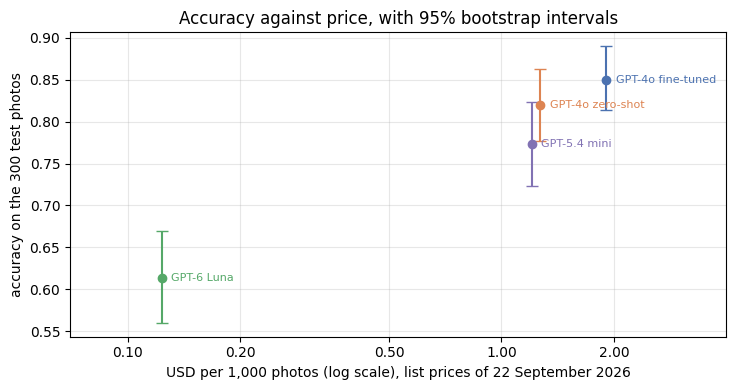

In [24]:
if PREDS and RECORDING:
    rows = []
    for c in ["gpt4o_finetuned_2026", "gpt4o_zeroshot_2026", "gpt6_luna_2026", "gpt54_mini_2026"]:
        if c not in PREDS or c not in RECORDING["models"]:
            continue
        stats = RECORDING["models"][c]
        rows.append({"model": COLUMNS[c], "accuracy": POINT[c][0], "accuracy 95% CI": interval(BOOT[c][:, 0]),
                     "macro F1": POINT[c][2], "macro F1 95% CI": interval(BOOT[c][:, 2]),
                     "USD per 1,000 photos": stats["usd_per_1000_photos"], "median seconds": stats["median_seconds"],
                     "tokens per photo": f"{stats['input_tokens'] / stats['calls_answered']:.0f} in, "
                                         f"{stats['output_tokens'] / stats['calls_answered']:.0f} out"})
    VERDICT = pd.DataFrame(rows).set_index("model")
    display(VERDICT.round({"accuracy": 3, "macro F1": 3, "USD per 1,000 photos": 2, "median seconds": 2}))

    fig, ax = plt.subplots(figsize=(7.5, 4))
    for (name, row), colour in zip(VERDICT.iterrows(), ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]):
        low, high = np.percentile(BOOT[[k for k, v in COLUMNS.items() if v == name][0]][:, 0], [2.5, 97.5])
        ax.errorbar(row["USD per 1,000 photos"], row["accuracy"], yerr=[[row["accuracy"] - low], [high - row["accuracy"]]],
                    fmt="o", color=colour, capsize=4)
        ax.annotate(name.replace(" 2026", ""), (row["USD per 1,000 photos"], row["accuracy"]), xytext=(7, 0),
                    textcoords="offset points", va="center", fontsize=8, color=colour)
    ax.set_xscale("log")
    ticks = [0.1, 0.2, 0.5, 1, 2]
    ax.set_xticks(ticks, [f"{t:.2f}" for t in ticks])
    ax.minorticks_off()
    ax.set_xlim(0.07, 4)
    ax.set_xlabel("USD per 1,000 photos (log scale), list prices of 22 September 2026")
    ax.set_ylabel("accuracy on the 300 test photos")
    ax.set_title("Accuracy against price, with 95% bootstrap intervals")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
elif not RECORDING:
    print("[ATTENTION] data/recording_2026.json is not available, so there are no costs to compare.")

**On this test set: yes, and at a price.** The fine-tune is the most accurate of the four models of 2026 — 0.850 accuracy, 0.859 macro F1 — and the most expensive, at USD 1.91 per 1,000 photos, one and a half times the price of its base model. Its lead over that base model, 0.030, is not distinguishable from zero on 300 photos, nor on the 205 photos without a near-copy (section 6.9); its leads over GPT-5.4 mini (0.077) and GPT-6 Luna (0.237) are clear.

The newest model is the weakest here. GPT-6 Luna costs USD 0.12 per 1,000 photos, about a fifteenth of the fine-tune's price, and classifies 61% of the photos correctly. Three caveats before anyone generalises:

- the article's prompt was written for GPT-4o and was not adapted for any other model;
- every model saw the photos at `"detail": "low"`, the article's setting, chosen for GPT-4o; as section 4.5 showed, the same setting buys each model a different number of image tokens, and open exercise 2 in section 9.7 is the place to test `"high"`;
- the six labels are the data set's, and some of Luna's "errors", such as "crack" for a shattered window, are defensible readings of the photo.

In money none of this is large: even the fine-tune costs about 0.2 US cents per photo. What matters more is what an error costs downstream — and that a fine-tune is tied to the organisation that trained it and to a base model that will eventually be retired, while a general model can change behind an unchanged name.

### 6.9 Near-copies across the split: a data-hygiene check

Image data sets often contain the same photo more than once: re-coloured, cropped, mirrored, or simply saved twice under two names. When the copies land on both sides of a split, a "test" photo is unseen in name only — its twin was a training photo — and a model that memorises can score on it without reading it. Section 3 checked that no test **file** is a training file; this section checks the **content**.

The method is simple enough to write out. Each photo is shrunk to 16 × 16 grey pixels. Two fingerprints are taken from that thumbnail:

- an **average hash**: 256 bits, one per pixel, set where the pixel is brighter than the thumbnail's mean. Two photos whose hashes differ in only a few bits look alike;
- the thumbnail itself, centred and scaled to length 1, so that the **correlation** of two photos is one dot product. It ignores overall brightness and contrast, and so survives a re-colouring.

Every test photo is compared with every training and validation photo, as it is and mirrored. It counts as a **near-copy** if some training or validation photo correlates with it at 0.95 or more, or lies at most 8 bits away. These thresholds were chosen by looking at pairs; exercise 4 in section 9.7 asks you to move them.

The screen needs the 300 test photos and the 1,200 training and validation photos as files — the full 1.6 GB download — so it was run once for this notebook and its result committed as `data/test300_near_copies.csv`. The flag below recomputes it: **a 1.6 GB download, and about twice that on disk while the archive is unpacked**; how long the download takes depends on your connection, and hashing the 1,500 photos then took about 9 seconds on the lecturer's laptop.

In [25]:
NEAR_COPY_CORR, NEAR_COPY_BITS = 0.95, 8  # a near-copy: correlation >= 0.95 or at most 8 of 256 bits apart
RECOMPUTE_NEAR_COPIES = False  # True: downloads the full data set (1.6 GB) and recomputes the screen - see above


def fingerprints(small: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # The 256-bit average hash and the centred, unit-length 16 x 16 thumbnail of one grey 16 x 16 image.
    centred = small.ravel() - small.mean()
    return small.ravel() > small.mean(), centred / (np.linalg.norm(centred) + 1e-9)


def near_copy_screen(queries: list[str], references: list[str], images: Path) -> pd.DataFrame:
    """For each query photo: the highest correlation and the smallest Hamming distance to any reference photo,
    with the query taken as it is and mirrored."""
    def grey16(name: str) -> np.ndarray:
        with Image.open(images / name) as image:
            return np.asarray(image.convert("L").resize((16, 16), Image.Resampling.LANCZOS), dtype=np.float32)

    ref = [fingerprints(grey16(name)) for name in references]
    ref_bits, ref_unit = np.array([b for b, _ in ref]), np.array([u for _, u in ref])
    max_corr, min_bits = np.full(len(queries), -1.0), np.full(len(queries), 257)
    small = [grey16(name) for name in queries]
    for mirrored in (False, True):
        query = [fingerprints(s[:, ::-1] if mirrored else s) for s in small]
        bits, unit = np.array([b for b, _ in query]), np.array([u for _, u in query])
        max_corr = np.maximum(max_corr, (unit @ ref_unit.T).max(axis=1))
        min_bits = np.minimum(min_bits, (bits[:, None, :] != ref_bits[None, :, :]).sum(axis=2).min(axis=1))
    return pd.DataFrame({"filename": queries, "max_corr": max_corr.round(4), "min_hamming": min_bits.astype(int)})


NEAR = None
if RECOMPUTE_NEAR_COPIES:
    with redirect_stderr(io.StringIO()):
        full_images = Path(kagglehub.dataset_download(KAGGLE_HANDLE)) / "train" / "train" / "images"  # 1.6 GB
    started = time.perf_counter()
    NEAR = near_copy_screen(test["filename"].tolist(), pd.concat([train, val])["filename"].tolist(), full_images)
    print(f"Screened 300 test photos against 1,200 training and validation photos in {time.perf_counter() - started:.0f} seconds.")
else:
    near_path = load_data_file("test300_near_copies.csv")
    if near_path is not None:
        NEAR = pd.read_csv(near_path)[["filename", "max_corr", "min_hamming"]]
        print("Read the precomputed screen from data/test300_near_copies.csv (RECOMPUTE_NEAR_COPIES is False).")

if NEAR is None:
    print("[ATTENTION] No near-copy screen is available, so the rest of section 6.9 has nothing to show.")
else:
    assert list(NEAR["filename"]) == list(test["filename"]), "the screen does not match the test set"
    NEAR["near_copy"] = (NEAR["max_corr"] >= NEAR_COPY_CORR) | (NEAR["min_hamming"] <= NEAR_COPY_BITS)
    NEAR_COPY = NEAR["near_copy"].to_numpy()
    print(f"Test photos with a near-copy among the training and validation photos: {NEAR_COPY.sum()} of {len(NEAR)}; "
          f"without one: {(~NEAR_COPY).sum()}.")
    print(f"  by correlation >= {NEAR_COPY_CORR}: {(NEAR['max_corr'] >= NEAR_COPY_CORR).sum()};  "
          f"by at most {NEAR_COPY_BITS} bits: {(NEAR['min_hamming'] <= NEAR_COPY_BITS).sum()}")
    display(pd.crosstab(test["label"].to_numpy(), NEAR["near_copy"].map({True: "near-copy", False: "clean"}).to_numpy(),
                        rownames=["class"], colnames=["test photos"]).reindex(LABELS))

Read the precomputed screen from data/test300_near_copies.csv (RECOMPUTE_NEAR_COPIES is False).
Test photos with a near-copy among the training and validation photos: 95 of 300; without one: 205.
  by correlation >= 0.95: 94;  by at most 8 bits: 75


test photos,clean,near-copy
class,,
crack,6,1
scratch,66,38
tire flat,18,4
dent,53,27
glass shatter,39,11
lamp broken,23,14


Two of the pairs, by name. In each, the test photo has a twin among the photos the fine-tune was trained or validated on — one mirrored and re-coloured, one only re-coloured. Open them side by side from the data set if you want to see how close they are; the notebook itself shows only the 12 gallery photos.

In [26]:
# Two of the pairs by name. Their photos are not shown: this notebook shows only the 12 gallery photos.
PAIRS_NAMED = [("1091.jpg", "618.jpg", "validation", "mirrored and re-coloured"),
               ("1077.jpg", "465.jpg", "training", "re-coloured")]
near_by_name = NEAR.set_index("filename") if NEAR is not None else None
pd.DataFrame(
    [
        {
            "test photo": test_name,
            "its twin": seen_name,
            "twin is a": f"{subset} photo",
            "how it differs": how,
            "correlation": round(float(near_by_name.loc[test_name, "max_corr"]), 3) if near_by_name is not None else None,
            "hash bits apart": int(near_by_name.loc[test_name, "min_hamming"]) if near_by_name is not None else None,
        }
        for test_name, seen_name, subset, how in PAIRS_NAMED
    ]
)

,test photo,its twin,twin is a,how it differs,correlation,hash bits apart
0,1091.jpg,618.jpg,validation photo,mirrored and re-coloured,0.985,29
1,1077.jpg,465.jpg,training photo,re-coloured,0.970,20


The metrics of section 6.3 once more, on all 300 test photos and on the photos without a near-copy, each with a 95% bootstrap interval. The clean set is resampled 2,000 times in the same way as in 6.3, with the same resamples for every model. The last column is the accuracy on the near-copies alone.

,"accuracy, all 300","accuracy, 205 clean","weighted F1, all 300","weighted F1, 205 clean","macro F1, all 300","macro F1, 205 clean","accuracy, 95 near-copies"
model,,,,,,,
CNN 2025,"0.833 [0.79, 0.87]","0.785 [0.73, 0.84]","0.827 [0.78, 0.87]","0.774 [0.71, 0.83]","0.761 [0.69, 0.84]","0.680 [0.63, 0.72]",0.937
GPT-4o zero-shot 2025,"0.797 [0.75, 0.84]","0.805 [0.75, 0.86]","0.797 [0.75, 0.84]","0.806 [0.75, 0.86]","0.769 [0.68, 0.83]","0.775 [0.67, 0.85]",0.779
GPT-4o fine-tuned 2025,"0.870 [0.83, 0.91]","0.893 [0.85, 0.93]","0.869 [0.83, 0.91]","0.892 [0.85, 0.93]","0.890 [0.84, 0.93]","0.917 [0.88, 0.95]",0.821
GPT-4o fine-tuned 2026,"0.850 [0.81, 0.89]","0.863 [0.81, 0.91]","0.848 [0.81, 0.89]","0.863 [0.81, 0.91]","0.859 [0.79, 0.91]","0.861 [0.78, 0.92]",0.821
GPT-4o zero-shot 2026,"0.820 [0.78, 0.86]","0.844 [0.79, 0.89]","0.822 [0.78, 0.86]","0.846 [0.79, 0.89]","0.821 [0.74, 0.88]","0.851 [0.76, 0.91]",0.768
GPT-6 Luna 2026,"0.613 [0.56, 0.67]","0.610 [0.54, 0.68]","0.629 [0.57, 0.69]","0.617 [0.55, 0.69]","0.601 [0.55, 0.65]","0.609 [0.54, 0.67]",0.621
GPT-5.4 mini 2026,"0.773 [0.72, 0.82]","0.795 [0.74, 0.85]","0.768 [0.71, 0.82]","0.792 [0.73, 0.85]","0.748 [0.66, 0.81]","0.749 [0.66, 0.83]",0.726


,all 300,205 clean
difference in accuracy,,
GPT-4o fine-tuned 2025 minus CNN 2025,"+0.037 [-0.01, 0.09]","+0.107 [0.05, 0.17]"
GPT-4o fine-tuned 2025 minus GPT-4o zero-shot 2025,"+0.073 [0.03, 0.12]","+0.088 [0.03, 0.15]"
GPT-4o fine-tuned 2026 minus GPT-4o zero-shot 2026,"+0.030 [-0.01, 0.07]","+0.020 [-0.03, 0.07]"


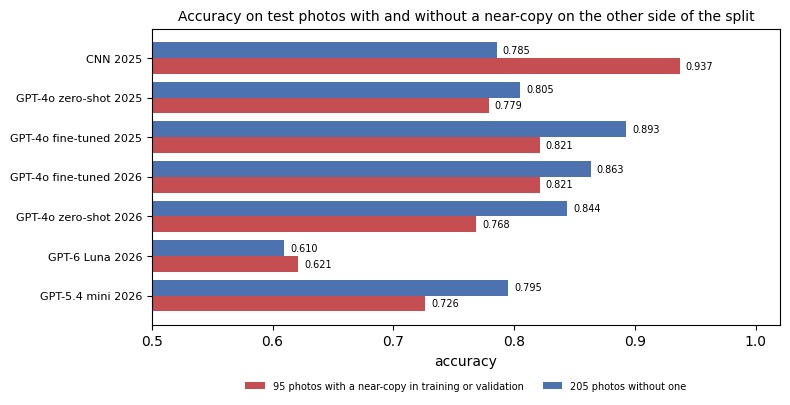

In [27]:
if PREDS and NEAR is not None:
    CLEAN = np.where(~NEAR_COPY)[0]
    RESAMPLES_CLEAN = np.random.default_rng(SEED).integers(0, len(CLEAN), size=(B, len(CLEAN)))
    BOOT_CLEAN = {c: np.array([three_metrics(Y_CODES[CLEAN][idx], p[CLEAN][idx]) for idx in RESAMPLES_CLEAN])
                  for c, p in P_CODES.items()}
    POINT_CLEAN = {c: three_metrics(Y_CODES[CLEAN], p[CLEAN]) for c, p in P_CODES.items()}

    def with_interval(point: float, values: np.ndarray) -> str:
        return f"{point:.3f} {interval(values)}"

    rows = []
    for c in PREDS:
        rows.append({
            "model": COLUMNS[c],
            f"accuracy, all {len(Y)}": with_interval(POINT[c][0], BOOT[c][:, 0]),
            f"accuracy, {len(CLEAN)} clean": with_interval(POINT_CLEAN[c][0], BOOT_CLEAN[c][:, 0]),
            f"weighted F1, all {len(Y)}": with_interval(POINT[c][1], BOOT[c][:, 1]),
            f"weighted F1, {len(CLEAN)} clean": with_interval(POINT_CLEAN[c][1], BOOT_CLEAN[c][:, 1]),
            f"macro F1, all {len(Y)}": with_interval(POINT[c][2], BOOT[c][:, 2]),
            f"macro F1, {len(CLEAN)} clean": with_interval(POINT_CLEAN[c][2], BOOT_CLEAN[c][:, 2]),
            f"accuracy, {NEAR_COPY.sum()} near-copies": f"{(PREDS[c][NEAR_COPY] == Y[NEAR_COPY]).mean():.3f}",
        })
    CLEAN_METRICS = pd.DataFrame(rows).set_index("model")
    display(CLEAN_METRICS)

    rows = []
    for a, b in [("gpt4o_finetuned_2025", "cnn_2025"), ("gpt4o_finetuned_2025", "gpt4o_zeroshot_2025"),
                 ("gpt4o_finetuned_2026", "gpt4o_zeroshot_2026")]:
        diff_all, diff_clean = BOOT[a] - BOOT[b], BOOT_CLEAN[a] - BOOT_CLEAN[b]
        rows.append({"difference in accuracy": f"{COLUMNS[a]} minus {COLUMNS[b]}",
                     f"all {len(Y)}": f"{POINT[a][0] - POINT[b][0]:+.3f} {interval(diff_all[:, 0])}",
                     f"{len(CLEAN)} clean": f"{POINT_CLEAN[a][0] - POINT_CLEAN[b][0]:+.3f} {interval(diff_clean[:, 0])}"})
    display(pd.DataFrame(rows).set_index("difference in accuracy"))

    fig, ax = plt.subplots(figsize=(8, 4.2))
    order = list(PREDS)
    y = np.arange(len(order))
    near_acc = [(PREDS[c][NEAR_COPY] == Y[NEAR_COPY]).mean() for c in order]
    clean_acc = [POINT_CLEAN[c][0] for c in order]
    ax.barh(y + 0.2, near_acc, height=0.4, color="#C44E52", label=f"{NEAR_COPY.sum()} photos with a near-copy in training or validation")
    ax.barh(y - 0.2, clean_acc, height=0.4, color="#4C72B0", label=f"{len(CLEAN)} photos without one")
    for yy, value in zip(list(y + 0.2) + list(y - 0.2), near_acc + clean_acc):
        ax.text(value + 0.005, yy, f"{value:.3f}", va="center", fontsize=7)
    ax.set_yticks(y, [COLUMNS[c] for c in order], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0.5, 1.02)
    ax.set_xlabel("accuracy")
    ax.set_title("Accuracy on test photos with and without a near-copy on the other side of the split", fontsize=10)
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()

**95 of the 300 test photos have a near-copy** among the 1,200 training and validation photos — about a third, in every class. The two pairs above are typical: the same photo, mirrored or re-coloured, under another file name.

What the near-copies do to the results:

- **They reward memorising.** The CNN, trained on the 900 training photos and nothing else, scores 0.937 on the 95 near-copies and 0.785 on the 205 clean photos. Without the near-copies its accuracy is 0.048 lower than on the full test set, and its macro F1 falls from 0.761 to 0.680.
- **The fine-tune does not profit.** Although it was trained on the same photos, it scores lower on the near-copies (0.821) than on the clean photos (0.893 in 2025, 0.863 in 2026). The general models, which have seen none of these photos, show the same pattern, with one exception: GPT-6 Luna, 0.621 against 0.610. This data cannot say why the near-copies are harder for the language models; the lesson does not depend on it.
- **On clean photos the fine-tune's lead grows.** Its 2025 lead over the CNN rises from +0.037 [−0.01, 0.09] on all 300 photos to +0.107 [0.05, 0.17] on the 205 clean ones, an interval that no longer includes zero, and its lead over zero-shot GPT-4o from +0.073 to +0.088.

**Near-copies across a split are a data-hygiene problem of any image data set**, not a quirk of this one: a file-name check does not find them, and they flatter exactly the model that memorises. Before training on photos — claim photos included — find the near-copies and put each group of them on one side of the split; then check the test set as this section does, and report the metrics on its clean part next to the rest.

---

## 7 More than a label

### Why it matters for actuaries

A damage class alone routes almost nothing. Whether a claim goes to a desk assessor, a field assessor or straight to a repair partner depends on where the damage is, how severe it is, and whether the photo is good enough to judge it. A CNN trained on six labels can give only the label. A vision language model can be asked for more in the same call — which is the article's secondary objective, and the reason to use a language model here at all.

### 7.1 Where is the damage? The article's second prompt

The article's second prompt adds a sentence on location to the first, rewrites step 3, replaces the output and example sections, and rewords a few lines; the schema adds an optional `location` field. Both are the research notebook's, word for word.

In [28]:
SYSTEM_PROMPT_incl_location = """
You will classify images of cars with visible damages into one of six specific classes.
Your task is to examine the image provided, identify the type of damage, and return the correct damage type as one of the predefined classes.
Additionally, if the location of the damage is identifiable, specify it concisely.
The six damage classes are as follows:

1. crack
2. scratch
3. tire flat
4. dent
5. glass shatter
6. lamp broken

# Steps

1. **Analyze the Image:**
   - Carefully inspect the image provided, focusing on visible damage to determine its type.
   - Pay attention to details such as patterns, locations, and characteristics of the damage to classify it accurately.

2. **Identify the Correct Class:**
   - Match the observed damage to one of the six predefined classes listed above.
   - Avoid ambiguous classifications and ensure the answer aligns precisely with the provided options.

3. **Determine and Output the Classification and Location:**
   - If the damage location is clear (e.g., "windshield" for glass shatter or "rear bumper" for a dent), include it in the response.
   - If the location cannot be determined with confidence, return only the damage class.

# Output Format:
- If the location is identifiable: `"damage type at location"` (e.g., `"glass shatter at windshield"`)
- If the location is unclear: `"damage type"` (e.g., `"scratch"`)

# Notes
- If multiple damage types appear equally prominent in the image, select the one that seems most severe or predominant.
- Ensure every response falls strictly within the six defined classes. Avoid assumptions or interpretations beyond these categories.

# Example Outputs:
For an input image with a visible scratch:
- **Correct Output:** `"scratch"`

For an input image showing a shattered windshield:
- **Correct Output:** `"glass shatter at windshield"`

For an input image with an unclear damage location:
- **Correct Output:** `"dent"`

Adhere strictly to this output format and classification criteria in every response.
"""


class DamageTypeAndLocation(BaseModel):
    prediction: Literal["crack", "scratch", "tire flat", "dent", "glass shatter", "lamp broken"]
    location: Optional[str]


print(json.dumps(DamageTypeAndLocation.model_json_schema(), indent=2))

{
  "properties": {
    "prediction": {
      "enum": [
        "crack",
        "scratch",
        "tire flat",
        "dent",
        "glass shatter",
        "lamp broken"
      ],
      "title": "Prediction",
      "type": "string"
    },
    "location": {
      "anyOf": [
        {
          "type": "string"
        },
        {
          "type": "null"
        }
      ],
      "title": "Location"
    }
  },
  "required": [
    "prediction",
    "location"
  ],
  "title": "DamageTypeAndLocation",
  "type": "object"
}


Read the prompt's **Output Format** section next to the schema and they disagree. The prompt asks for one string, `"glass shatter at windshield"`; the schema has two fields, `prediction` and `location`. With structured outputs **the schema wins** wherever it pins the answer down: the provider constrains the answer to the schema, so `prediction` can hold nothing but a class name, whatever the prompt says. `location`, though, is free text, and a prompt that describes a different format from the one it gets invites confusion there. Whether that changes the *content* of the answers is an empirical question.

Below is a corrected version: three passages changed so that the prompt describes the schema it travels with, and nothing else touched.

In [29]:
CORRECTIONS = [
    ("   - If the location cannot be determined with confidence, return only the damage class.",
     "   - If the location cannot be determined with confidence, set the location to null."),
    ("""- If the location is identifiable: `"damage type at location"` (e.g., `"glass shatter at windshield"`)
- If the location is unclear: `"damage type"` (e.g., `"scratch"`)""",
     """- Put the damage class in the field `prediction` and the location in the field `location`.
- If the location is unclear, set `location` to null."""),
    ("""For an input image with a visible scratch:
- **Correct Output:** `"scratch"`

For an input image showing a shattered windshield:
- **Correct Output:** `"glass shatter at windshield"`

For an input image with an unclear damage location:
- **Correct Output:** `"dent"`""",
     """For an input image with a visible scratch on the rear bumper:
- **Correct Output:** `{"prediction": "scratch", "location": "rear bumper"}`

For an input image showing a shattered windshield:
- **Correct Output:** `{"prediction": "glass shatter", "location": "windshield"}`

For an input image with an unclear damage location:
- **Correct Output:** `{"prediction": "dent", "location": null}`"""),
]
SYSTEM_PROMPT_LOCATION = SYSTEM_PROMPT_incl_location
for old, new in CORRECTIONS:
    assert old in SYSTEM_PROMPT_LOCATION, "a passage to correct was not found"
    SYSTEM_PROMPT_LOCATION = SYSTEM_PROMPT_LOCATION.replace(old, new)

for number, (old, new) in enumerate(CORRECTIONS, start=1):
    print(f"--- change {number}, before:")
    print(old)
    print(f"--- change {number}, after:")
    print(new)
    print()

--- change 1, before:
   - If the location cannot be determined with confidence, return only the damage class.
--- change 1, after:
   - If the location cannot be determined with confidence, set the location to null.

--- change 2, before:
- If the location is identifiable: `"damage type at location"` (e.g., `"glass shatter at windshield"`)
- If the location is unclear: `"damage type"` (e.g., `"scratch"`)
--- change 2, after:
- Put the damage class in the field `prediction` and the location in the field `location`.
- If the location is unclear, set `location` to null.

--- change 3, before:
For an input image with a visible scratch:
- **Correct Output:** `"scratch"`

For an input image showing a shattered windshield:
- **Correct Output:** `"glass shatter at windshield"`

For an input image with an unclear damage location:
- **Correct Output:** `"dent"`
--- change 3, after:
For an input image with a visible scratch on the rear bumper:
- **Correct Output:** `{"prediction": "scratch", "lo

Both prompts now go to the fine-tune, on the same twelve photos: 24 calls.

In [30]:
LOCATION_PROMPTS = {"article": SYSTEM_PROMPT_incl_location, "corrected": SYSTEM_PROMPT_LOCATION}


def location_job(job: tuple[str, str]) -> dict:
    variant, name = job
    row = {"prompt": variant, "filename": name, "prediction": None, "location": None, "source": None, "error": None}
    if can_call(MODEL_FINETUNED):
        record = ask_about_photo(GALLERY_PATHS[name], MODEL_FINETUNED, instructions=LOCATION_PROMPTS[variant],
                                 schema=DamageTypeAndLocation, purpose="location")
        if record["error"] is None:
            row.update(prediction=record["parsed"].prediction, location=record["parsed"].location, source="live")
        elif not NO_CREDIT["flag"]:
            row.update(source="failed", error=record["error"])
    if row["source"] is None:  # the model is not available to this key, or the key has no credit left
        row.update(prediction=recorded_answer(name, f"ft_{variant}_prediction"),
                   location=recorded_answer(name, f"ft_{variant}_location"))
        row["source"] = "recorded" if row["prediction"] else "missing"
    return row


jobs = [(variant, name) for variant in LOCATION_PROMPTS for name in GALLERY["filename"]]
with ThreadPoolExecutor(max_workers=8) as pool:
    LOCATION = pd.DataFrame(list(pool.map(location_job, jobs)))
LOCATION["model"] = "location, " + LOCATION["prompt"]
report_failures(LOCATION)
if (LOCATION["source"] == "recorded").any():
    print("[ATTENTION] The answers below are the ones recorded in the run saved here, not live.")

LOCATION_TABLE = GALLERY.set_index("filename")[["label"]]
for variant in LOCATION_PROMPTS:
    part = LOCATION[LOCATION["prompt"] == variant].set_index("filename")
    LOCATION_TABLE = LOCATION_TABLE.join(part[["prediction", "location"]].add_prefix(f"{variant}: "))
display(LOCATION_TABLE.fillna("-"))
for variant in LOCATION_PROMPTS:
    part = LOCATION_TABLE[f"{variant}: prediction"]
    print(f"{variant:<9} prompt: {int((part == LOCATION_TABLE['label']).sum())} of 12 classes right, "
          f"{int(LOCATION_TABLE[f'{variant}: location'].notna().sum())} locations given")

[PASS] No call failed.


,label,article: prediction,article: location,corrected: prediction,corrected: location
filename,,,,,
4779.jpg,crack,crack,front bumper,crack,front bumper
4150.jpg,crack,crack,-,crack,-
3050.jpg,scratch,scratch,-,scratch,front bumper
5201.jpg,scratch,scratch,-,scratch,rear bumper
1525.jpg,tire flat,tire flat,-,tire flat,-
6747.jpg,tire flat,tire flat,-,tire flat,-
5395.jpg,dent,dent,front door,dent,door
7192.jpg,dent,dent,driver's side door,dent,-
2543.jpg,glass shatter,glass shatter,windshield,glass shatter,windshield


article   prompt: 12 of 12 classes right, 5 locations given
corrected prompt: 12 of 12 classes right, 6 locations given


What the two prompts produced:

- **The schema held the format — almost.** Every answer arrived as two fields, a class name in `prediction` and a part of the car or null in `location`, and every class was right under both prompts. But the article's prompt, which asks for "damage type at location", leaked into the one field the schema leaves free: for 4443.jpg its location reads "at windshield", where the corrected prompt gives "windshield". A schema constrains the shape of an answer; its free-text fields are still steered by the prompt around them.
- **The locations moved more than the classes.** The article's prompt names a location for 5 photos, the corrected one for 6. They agree on 4779.jpg, 2543.jpg and — the stray "at" aside — 4443.jpg; they disagree on 3050.jpg and 5201.jpg (no location, then "front bumper" and "rear bumper"), on 5395.jpg ("front door", then "door") and on 7192.jpg ("driver's side door", then none). Both prompts ran at `temperature=0`, which reduces run-to-run variation but does not guarantee identical answers, so twelve photos cannot separate the effect of the wording from that variation.
- **A location can be confidently wrong.** 4443.jpg shows a smashed rear window, and both prompts call it the windshield. "Driver's side" for 7192.jpg is a guess the photo cannot support: which side the driver sits on depends on the country.

### 7.2 A richer assessment with GPT-6 Luna

Now the full triage record, in one call per photo, from GPT-6 Luna: the damage class, the damaged part, the side of the car, a severity grade, the quality of the photo, whether there is more than one kind of damage, and whether a human should look — with a reason. The prompt and the schema are written for this notebook, not taken from the article. As in `04`, the field descriptions travel inside the JSON schema, so they are part of the prompt: they are where the severity grades are defined.

In [31]:
ASSESSMENT_PROMPT = """
You assist the motor claims team of an insurer at first notice of loss. You receive one photo of a damaged car.
Describe only what is visible in the photo and fill in every field of the schema. Do not guess the make, the
model or the registration of the car. If several kinds of damage are visible, classify the most severe or
predominant one and set multiple_damages to true. Set needs_human_review to true whenever a claims handler
should look at the photo before any decision, and give the reason in review_reason; otherwise set it to null.
"""


class DamageAssessment(BaseModel):
    damage_class: Literal["crack", "scratch", "tire flat", "dent", "glass shatter", "lamp broken"]
    damaged_part: str = Field(description='The part that carries the damage, in a few words, e.g. "rear bumper", '
                                          '"windscreen", "front left tyre"; "not determinable" if unclear.')
    vehicle_side: Literal["front", "rear", "left", "right", "top", "not_determinable"]
    severity: Literal["minor", "moderate", "severe", "not_determinable"] = Field(
        description="minor: cosmetic, repairable without replacing a part; moderate: at least one part needs "
                    "repair or replacement; severe: structural damage or several parts affected, the car may "
                    "not be safe to drive; not_determinable: the photo does not allow a judgement.")
    image_quality: Literal["good", "acceptable", "poor"] = Field(
        description="poor: blurred, dark, heavily grainy or cropped so tightly that the damage cannot be judged.")
    multiple_damages: bool = Field(description="True if more than one kind of damage is visible.")
    needs_human_review: bool
    review_reason: Optional[str]


RICH_FIELDS = list(DamageAssessment.model_fields)


def assessment_job(name: str) -> dict:
    row = {"filename": name, "source": None, "error": None, **{f: None for f in RICH_FIELDS}}
    if can_call(MODEL_NOW):
        record = ask_about_photo(GALLERY_PATHS[name], MODEL_NOW, instructions=ASSESSMENT_PROMPT,
                                 schema=DamageAssessment, purpose="assessment")
        if record["error"] is None:
            row.update(record["parsed"].model_dump(), source="live")
        elif not NO_CREDIT["flag"]:
            row.update(source="failed", error=record["error"])
    if row["source"] is None:  # the model is not available to this key, or the key has no credit left
        row.update({f: recorded_answer(name, f"rich_{f}") for f in RICH_FIELDS})
        row["source"] = "recorded" if row["damage_class"] else "missing"
    return row


with ThreadPoolExecutor(max_workers=8) as pool:
    ASSESSMENT = pd.DataFrame(list(pool.map(assessment_job, GALLERY["filename"])))
ASSESSMENT["model"] = "GPT-6 Luna, assessment"
report_failures(ASSESSMENT)
if (ASSESSMENT["source"] == "recorded").any():
    print("[ATTENTION] The answers below are the ones recorded in the run saved here, not live.")

ASSESSMENT_TABLE = GALLERY.set_index("filename")[["label"]].join(ASSESSMENT.set_index("filename")[RICH_FIELDS])
with pd.option_context("display.max_colwidth", 70):
    display(ASSESSMENT_TABLE)
print(f"Damage class right: {int((ASSESSMENT_TABLE['damage_class'] == ASSESSMENT_TABLE['label']).sum())} of 12")

[PASS] No call failed.


,label,damage_class,damaged_part,vehicle_side,severity,image_quality,multiple_damages,needs_human_review,review_reason
filename,,,,,,,,,
4779.jpg,crack,crack,"vehicle glass, likely windscreen",not_determinable,moderate,acceptable,False,True,"The crack is extensive, and the exact glass panel and repair or re..."
4150.jpg,crack,crack,body panel around wheel arch,not_determinable,moderate,acceptable,False,True,"The panel is visibly cracked, but the close crop and angle make th..."
3050.jpg,scratch,scratch,side body panel near wheel,not_determinable,minor,acceptable,False,False,None
5201.jpg,scratch,scratch,"body panel, exact part unclear",not_determinable,not_determinable,poor,False,True,"The close, blurry, partially obscured view makes it difficult to i..."
1525.jpg,tire flat,tire flat,tyre,not_determinable,moderate,acceptable,False,True,"The tyre appears compressed at the bottom, suggesting it may be fl..."
6747.jpg,tire flat,tire flat,visible wheel tyre,not_determinable,not_determinable,acceptable,False,True,"The tyre appears possibly deflated, but the image does not clearly..."
5395.jpg,dent,dent,front right door,right,not_determinable,good,False,True,"Possible shallow dent or panel distortion, but reflections and sha..."
7192.jpg,dent,dent,side door and adjacent body panel,not_determinable,moderate,acceptable,False,True,The side panel is substantially deformed near a door seam or pilla...
2543.jpg,glass shatter,glass shatter,windscreen,front,moderate,acceptable,False,True,The windscreen appears extensively shattered; reflections obscure ...


Damage class right: 11 of 12


In the saved run: one call per photo, a full record back, USD 0.0040 for all twelve (the bill at the end has it). GPT-6 Luna manages its own sampling, so a rerun changes several of these fields — and with them the photos the rules below select. Read it critically:

- **The class is right for 11 of the 12 photos.** The miss is 6101.jpg, a smashed headlamp, which becomes glass shatter on a "rear lamp".
- **Some fields are confidently wrong.** The bumper crack of 4779.jpg is put on "vehicle glass, likely windscreen", and the headlamp of 6101.jpg becomes a rear lamp. These are exactly the errors no metric in this notebook can catch, because the data set has no labels for them.
- **Severity is mostly "moderate"**: eight photos, with one minor (3050.jpg), three not determinable and none severe.
- **The model's own review flag fires for 11 of the 12 photos**, each with a sensible-sounding reason. A flag that fires for nearly every photo saves the claims team no work.

### 7.3 From fields to review rules

A model's own "needs review" flag is one more model output, and it is hard to audit why it fires. Deterministic rules on the structured fields are easy to audit: anyone can read them, and they give the same answer every time they are applied to the same record. Three simple rules, each sending a photo to a human:

- **R1 severe** — the severity is `severe`: a large claim, or a car that may not be safe to drive, warrants an assessor;
- **R2 cannot judge** — the image quality is `poor` or the severity is `not_determinable`: ask for a better photo;
- **R3 models disagree** — GPT-6 Luna's damage class differs from the fine-tune's answer of section 5: two independent readings of the same photo that do not match.

In [32]:
finetune_class = LIVE_TABLE["GPT-4o fine-tuned"]
RULES = {
    "R1 severe": lambda r: r["severity"] == "severe",
    "R2 cannot judge": lambda r: r["image_quality"] == "poor" or r["severity"] == "not_determinable",
    "R3 models disagree": lambda r: (pd.notna(r["damage_class"]) and pd.notna(finetune_class[r.name])
                                     and r["damage_class"] != finetune_class[r.name]),
}
if ASSESSMENT_TABLE["damage_class"].isna().any():
    print(f"[ATTENTION] {ASSESSMENT_TABLE['damage_class'].isna().sum()} assessment(s) missing: no rule can fire for them.")
flags = pd.DataFrame({rule: ASSESSMENT_TABLE.apply(test_rule, axis=1) for rule, test_rule in RULES.items()})
flags["any rule"] = flags.any(axis=1)
flags["model flag"] = ASSESSMENT_TABLE["needs_human_review"].astype(bool)
display(flags.map(lambda sent: "review" if sent else ""))

summary = pd.DataFrame({
    "photos sent to a human": flags.sum().astype(int),
    "which": [", ".join(flags.index[flags[c]]) for c in flags.columns],
})
display(summary)
agree = int((flags["any rule"] == flags["model flag"]).sum())
both = int((flags["any rule"] & flags["model flag"]).sum())
print(f"The rules and the model's own flag agree on {agree} of 12 photos; both send {both} photo(s) to a human.")

,R1 severe,R2 cannot judge,R3 models disagree,any rule,model flag
filename,,,,,
4779.jpg,,,,,review
4150.jpg,,,,,review
3050.jpg,,,,,
5201.jpg,,review,,review,review
1525.jpg,,,,,review
6747.jpg,,review,,review,review
5395.jpg,,review,,review,review
7192.jpg,,,,,review
2543.jpg,,,,,review


,photos sent to a human,which
R1 severe,0,
R2 cannot judge,4,"5201.jpg, 6747.jpg, 5395.jpg, 4597.jpg"
R3 models disagree,1,6101.jpg
any rule,5,"5201.jpg, 6747.jpg, 5395.jpg, 6101.jpg, 4597.jpg"
model flag,11,"4779.jpg, 4150.jpg, 5201.jpg, 1525.jpg, 6747.jpg, 5395.jpg, 7192.jpg, 2543.jpg, 4443.jpg, 6101.jpg, 4597.jpg"


The rules and the model's own flag agree on 6 of 12 photos; both send 5 photo(s) to a human.


In the saved run, the rules send 5 of the 12 photos to a human, each for a stated reason: 5201.jpg, 6747.jpg, 5395.jpg and 4597.jpg because the photo is poor or its severity cannot be judged; 6101.jpg because GPT-6 Luna and the fine-tune disagree on the class. No photo is graded severe, so R1 sends none. The model's own flag sends 11, including all 5 of those.

How often the two agree is not the point. The point is that the rules can be read, audited and tested, and that each threshold is a business decision — how many photos the claims team can review, and which errors are expensive — rather than something left to a model. Because the fields come from a model that samples, the rules are only as stable as those fields: rerun 7.2 and the set of photos sent to a human changes. Deterministic rules on non-deterministic inputs still need monitoring.

**A caveat that no table can remove.** The data set labels the damage class and nothing else. There is no ground truth for location, side, severity or image quality, so none of these fields can be scored here — they can only be checked by a person looking at the photo, as the article did for its locations. A severity grade that reads plausibly is still an unvalidated model output. Before such fields drive routing in production, they need their own labelled sample, their own metrics and their own monitoring.

In [33]:
# The answers of sections 5 and 7 for the twelve gallery photos are always saved for this session in _local/.
# With RECORD_GALLERY = True they also replace data/gallery_predictions_2026.csv - the answers other keys fall back on.
RECORD_GALLERY = False

if not ((LIVE["source"] == "live").all() and (LOCATION["source"] == "live").all() and (ASSESSMENT["source"] == "live").all()):
    print("[ATTENTION] Not every answer above is live and complete, so nothing was saved.")
else:
    saved = GALLERY[["filename", "label"]].set_index("filename")
    for label, (model, column) in LIVE_MODELS.items():
        saved[column] = LIVE_TABLE[label]
    for variant in LOCATION_PROMPTS:
        saved[f"ft_{variant}_prediction"] = LOCATION_TABLE[f"{variant}: prediction"]
        saved[f"ft_{variant}_location"] = LOCATION_TABLE[f"{variant}: location"]
    for field in RICH_FIELDS:
        saved[f"rich_{field}"] = ASSESSMENT_TABLE[field]
    text = saved.reset_index().to_csv(index=False, lineterminator="\n")
    (LOCAL_DIR / "session").mkdir(exist_ok=True)
    write_atomically(LOCAL_DIR / "session" / "gallery_predictions_2026.csv", text)
    print(f"This session's answers: _local/session/gallery_predictions_2026.csv ({saved.shape[0]} photos, {saved.shape[1]} columns).")
    if RECORD_GALLERY:
        DATA_DIR.mkdir(exist_ok=True)
        write_atomically(DATA_DIR / "gallery_predictions_2026.csv", text)
        print("[PASS] data/gallery_predictions_2026.csv replaced by this session's answers.")
    else:
        print("RECORD_GALLERY is False: data/gallery_predictions_2026.csv is left as it is.")

This session's answers: _local/session/gallery_predictions_2026.csv (12 photos, 16 columns).
RECORD_GALLERY is False: data/gallery_predictions_2026.csv is left as it is.


---

## 8 What to take away

- **A vision model is a few lines of plain code.** The photo becomes base64 text, the article's prompt and a six-value schema go with it, and a validated label comes back — USD 0.0019 per photo on the fine-tune.
- **What a photo costs depends on the model and the `detail` setting, not only on the price per token**: for the same photo at `"low"`, 85 tokens on GPT-4o, 231 on GPT-6 Luna, 706 on GPT-5.4 mini.
- **Score a model on photos it has never seen — by content, not only by file name.** None of the 300 test files is a training or validation file, yet 95 of the 300 test photos have a near-copy among them. Near-copies reward memorising: the CNN scores 0.937 on them and 0.785 on the rest.
- **Fine-tuning helped, and moved the errors.** In the research notebook's saved run, accuracy rose from 0.797 to 0.870 and macro F1 from 0.769 to 0.890. Fine-tuning fixed 40 photos and broke 18, trading over-called dents for under-called ones. On the 205 clean test photos the fine-tune scores 0.893, and its lead over the CNN grows from +0.037 to +0.107.
- **Report an interval with every metric.** On 300 photos an accuracy carries roughly ±0.04. In 2026 the fine-tune's lead over its own base model (+0.030) is within that noise; its leads over GPT-5.4 mini and GPT-6 Luna are not.
- **Newer is not better by default.** GPT-6 Luna, about fifteen times cheaper per photo than the fine-tune, classified 61% of the test photos correctly against the fine-tune's 85%, with the article's prompt and settings. Every change of model needs the same test before it goes live.
- **Answers are not fully repeatable.** Eighteen months apart, through a different interface and at a different temperature, the fine-tune changed 15 of its 300 answers: pin versions and settings, record them, and re-test after every change.
- **Beyond the label, check by hand.** Location, severity and image quality come in the same call, but without ground truth they remain unvalidated. Turn them into simple, auditable review rules and keep a human in the loop.
- **A damage photo can be faked with two API calls**, and the provenance record that marks it disappears with one re-save — section 9.

---

## 9 Extra exercise: faking the damage

> **An extra for those who finish early.** Nothing in sections 1–8 depends on it. It is an **awareness exercise for insurers**: it shows how little it takes to fake a damage photo, so that you can judge the controls that should catch one. Every generated image is labelled **SYNTHETIC** wherever it is shown. The base image is a car generated from a text prompt — never a real photo — and the exercise costs about USD 0.02 in image generation, plus a few classification calls.

### Why it matters for actuaries

The models that read damage photos can also make them. The article puts it plainly: a car without damage could be altered to show realistic damage at a chosen location and severity, without any skill in image editing. For a motor portfolio that means inflated or invented claims, supported by photos that look like every other photo in the claims system. Knowing what such a fake looks like, what a classifier makes of it, and what traces it carries is the starting point for any control.

### 9.1 A car that does not exist

One call to the image model generates an undamaged, generic hatchback. The prompt asks for blank number plates, no badges and no people. `quality="low"` keeps the price down; the image is 1,024 pixels square. A live run generates a different car and a different dent each time; the text below describes the pair saved here, which is also in `data/` for keys without the image model.

In [34]:
SYNTH_DIR = LOCAL_DIR / "synthetic"
SYNTH_DIR.mkdir(exist_ok=True)
BASE_CAR, DENTED_CAR = SYNTH_DIR / "synthetic_base_car.png", SYNTH_DIR / "synthetic_dent.png"

GEN_PROMPT = ("Photorealistic photo of an undamaged, generic mid-size five-door hatchback car parked on a quiet "
              "residential street in daylight, three-quarter side view showing the full side of the car including "
              "both doors. Plain silver paint, no brand logos or badges, no licence plate text (blank plates), "
              "no people, no readable text anywhere.")
EDIT_PROMPT = ("Add a realistic dent to the rear door of the car: a shallow, fist-sized inward deformation with "
               "slightly creased paint and natural reflections. Keep everything else exactly the same: same car, "
               "colour, lighting, background, camera angle and framing.")


def image_call_cost(usage) -> tuple[float, str]:
    # Cost of one image call from its usage fields: text and image input, and image output, priced separately.
    details = usage.input_tokens_details
    text_in, image_in, out = details.text_tokens, details.image_tokens, usage.output_tokens
    cost = (text_in * IMAGE_PRICES_USD_PER_MTOK["text in"] + image_in * IMAGE_PRICES_USD_PER_MTOK["image in"]
            + out * IMAGE_PRICES_USD_PER_MTOK["image out"]) / 1e6
    return cost, f"{text_in} text tokens and {image_in} image tokens in, {out} image tokens out"


def save_image(response, path: Path) -> None:
    partial = path.with_name(path.name + ".part")
    partial.write_bytes(base64.b64decode(response.data[0].b64_json))
    os.replace(partial, path)


def recorded_image(name: str) -> Path | None:
    # The image saved with this notebook, from data/, for keys without the image model.
    return load_data_file(name)


SYNTHETIC_SOURCE = "live"
if can_call(MODEL_IMAGE):
    try:
        started = time.perf_counter()
        response = with_retry(lambda: client.images.generate(model=MODEL_IMAGE, prompt=GEN_PROMPT, size="1024x1024",
                                                             quality="low", n=1, output_format="png"))
        seconds = time.perf_counter() - started
        save_image(response, BASE_CAR)
        cost, detail = image_call_cost(response.usage)
        log_usage(MODEL_IMAGE, "synthetic images", response.usage.input_tokens, 0, response.usage.output_tokens, cost=cost)
        print(f"Generated : {BASE_CAR.name}, {BASE_CAR.stat().st_size:,} bytes, in {seconds:.1f} seconds")
        print(f"Usage     : {detail}")
        print(f"Cost      : USD {cost:.5f}")
    except Exception as exc:
        print(f"[ATTENTION] The generation failed ({short_error(exc)}); the recorded image is used instead.")
        SYNTHETIC_SOURCE = "recorded"
else:
    print("[ATTENTION] The image model is not available to this key; the image saved in data/ is used.")
    SYNTHETIC_SOURCE = "recorded"
if SYNTHETIC_SOURCE == "recorded":
    BASE_CAR = recorded_image("synthetic_base_car.png") or BASE_CAR

Generated : synthetic_base_car.png, 2,220,125 bytes, in 11.8 seconds
Usage     : 74 text tokens and 0 image tokens in, 196 image tokens out
Cost      : USD 0.00625


### 9.2 A dent that never happened

A second call edits that image: it receives the image and a short instruction, and returns the same scene with a dent in the rear door. This is the whole of the "skill" the article warns about — one sentence of English.

Edited    : synthetic_dent.png, 2,038,828 bytes, in 13.3 seconds
Usage     : 65 text tokens and 1024 image tokens in, 196 image tokens out
Cost      : USD 0.01440


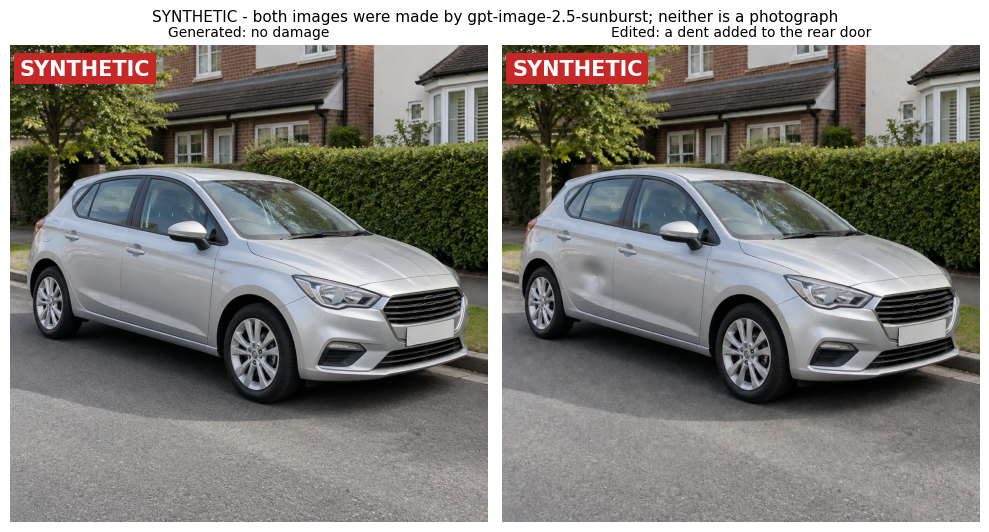

In [35]:
if SYNTHETIC_SOURCE == "live":
    try:
        started = time.perf_counter()
        base_image = (BASE_CAR.name, BASE_CAR.read_bytes(), "image/png")  # bytes, so that a retry sends them again
        response = with_retry(lambda: client.images.edit(model=MODEL_IMAGE, image=base_image, prompt=EDIT_PROMPT,
                                                         size="1024x1024", quality="low", n=1, output_format="png"))
        seconds = time.perf_counter() - started
        save_image(response, DENTED_CAR)
        cost, detail = image_call_cost(response.usage)
        log_usage(MODEL_IMAGE, "synthetic images", response.usage.input_tokens, 0, response.usage.output_tokens, cost=cost)
        print(f"Edited    : {DENTED_CAR.name}, {DENTED_CAR.stat().st_size:,} bytes, in {seconds:.1f} seconds")
        print(f"Usage     : {detail}")
        print(f"Cost      : USD {cost:.5f}")
    except Exception as exc:
        print(f"[ATTENTION] The edit failed ({short_error(exc)}); the recorded pair is used instead.")
        SYNTHETIC_SOURCE = "recorded"
        BASE_CAR = recorded_image("synthetic_base_car.png") or BASE_CAR
if SYNTHETIC_SOURCE == "recorded":
    DENTED_CAR = recorded_image("synthetic_dent.png") or DENTED_CAR

if BASE_CAR.exists() and DENTED_CAR.exists():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5.4), dpi=100)
    for ax, path, title in [(axes[0], BASE_CAR, "Generated: no damage"), (axes[1], DENTED_CAR, "Edited: a dent added to the rear door")]:
        with Image.open(path) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        ax.text(0.02, 0.97, "SYNTHETIC", transform=ax.transAxes, va="top", ha="left", color="white", fontsize=15,
                fontweight="bold", bbox={"facecolor": "#C62828", "edgecolor": "none", "pad": 4})
    fig.suptitle(f"SYNTHETIC - both images were made by {MODEL_IMAGE}; neither is a photograph", fontsize=11)
    fig.tight_layout()
    plt.show()
else:
    print("[ATTENTION] No synthetic images are available, so sections 9.3 to 9.5 have nothing to work on.")

In the run saved here: two calls, USD 0.021 in total — USD 0.00625 for the generation and USD 0.0144 for the edit, which costs more because the base image goes back in as 1,024 image tokens. The edit kept everything else — the houses, the hedge, the light, the blank number plate — and pressed a shallow dent into the rear door, with reflections that follow it. Nothing in the pixels says which of the two is the original.

### 9.3 What the classifier makes of it

The fake goes to the fine-tuned model of section 4, first with the article's classification prompt, then with the corrected location prompt of section 7.1. So does the undamaged original. Note what the six-class schema forces: it has no "no damage" option, so an undamaged car must still be put into one of the six classes.

In [36]:
classifier = MODEL_FINETUNED if can_call(MODEL_FINETUNED) else MODEL_BASE if can_call(MODEL_BASE) else None
SYNTHETIC_ANSWERS = None
if classifier is None or not (BASE_CAR.exists() and DENTED_CAR.exists()):
    recorded = load_data_file("synthetic_predictions_2026.csv")
    print("[ATTENTION] Nothing was classified: no key, no GPT-4o model visible to it, or no images.")
    if recorded is not None:
        print("            The answers recorded in the run saved here, for the pair in data/:")
        SYNTHETIC_ANSWERS = pd.read_csv(recorded)
else:
    if classifier != MODEL_FINETUNED:
        print("[ATTENTION] The fine-tuned model is not available to this key; its base model classifies instead.")
    tasks = [(image, prompt_name, prompt, schema)
             for image in [DENTED_CAR, BASE_CAR]
             for prompt_name, prompt, schema in [("classification", SYSTEM_PROMPT, DamageType),
                                                 ("with location", SYSTEM_PROMPT_LOCATION, DamageTypeAndLocation)]]
    with ThreadPoolExecutor(max_workers=4) as pool:
        records = list(pool.map(lambda t: ask_about_photo(t[0], classifier, instructions=t[2], schema=t[3],
                                                          purpose="synthetic images, classified"), tasks))
    rows = []
    for (image, prompt_name, _, _), record in zip(tasks, records):
        parsed = record["parsed"]
        rows.append({"image (SYNTHETIC)": "with the dent" if image == DENTED_CAR else "undamaged original",
                     "prompt": prompt_name, "model": MODEL_LABELS[classifier],
                     "prediction": parsed.prediction if parsed else f"failed: {record['error']}",
                     "location": getattr(parsed, "location", None) if parsed else None,
                     "tokens in": record["input_tokens"], "cost (USD)": round(record["cost_usd"], 5)})
    SYNTHETIC_ANSWERS = pd.DataFrame(rows)
    # Saved for this session in _local/; with RECORD_GALLERY = True (section 7.3) also as data/synthetic_predictions_2026.csv.
    text = SYNTHETIC_ANSWERS.to_csv(index=False, lineterminator="\n")
    (LOCAL_DIR / "session").mkdir(exist_ok=True)
    write_atomically(LOCAL_DIR / "session" / "synthetic_predictions_2026.csv", text)
    if RECORD_GALLERY and SYNTHETIC_SOURCE == "live":
        write_atomically(DATA_DIR / "synthetic_predictions_2026.csv", text)
if SYNTHETIC_ANSWERS is not None:
    display(SYNTHETIC_ANSWERS)

,image (SYNTHETIC),prompt,model,prediction,location,tokens in,cost (USD)
0,with the dent,classification,GPT-4o fine-tuned,dent,None,482,0.00190
1,with the dent,with location,GPT-4o fine-tuned,dent,rear door,622,0.00250
2,undamaged original,classification,GPT-4o fine-tuned,dent,None,482,0.00190
3,undamaged original,with location,GPT-4o fine-tuned,dent,None,622,0.00248


In the run saved here, the fine-tune calls the fake a dent, and with the location prompt puts it on the "rear door" — exactly where the edit put it, and exactly the answer a fraudulent claim would want. It also calls the undamaged original a dent. That is not a malfunction: the schema offers six kinds of damage and no way to say "none", so the model has to choose one of them. A classifier built to sort damage is not a check for whether there is damage, let alone whether the damage is real. Open exercise 1 adds the missing option.

### 9.4 What the file says about itself

A PNG file is a signature of 8 bytes followed by **chunks**, each written as its length, a four-letter type, the data and a checksum. `IHDR` holds the size, `IDAT` the pixels, `IEND` closes the file. A few lines of plain Python walk through them — no extra package needed.

In [37]:
PNG_SIGNATURE = b"\x89PNG\r\n\x1a\n"


def png_chunks(data: bytes) -> list[tuple[str, int, bytes]]:
    # Walk a PNG file: after the signature, chunks of [4-byte length][4-byte type][data][4-byte checksum].
    assert data[:8] == PNG_SIGNATURE, "not a PNG file"
    chunks, position = [], 8
    while position < len(data):
        length = struct.unpack(">I", data[position:position + 4])[0]
        kind = data[position + 4:position + 8].decode("latin-1")
        chunks.append((kind, length, data[position + 8:position + 8 + length]))
        position += 12 + length
    return chunks


FILES = {"undamaged original": BASE_CAR, "with the dent": DENTED_CAR}
for label, path in FILES.items():
    if not path.exists():
        continue
    data = path.read_bytes()
    print(f"{label} ({path.name}, {len(data):,} bytes, SYNTHETIC):")
    for kind, length, _ in png_chunks(data):
        print(f"    {kind}  {length:>10,} bytes")

undamaged original (synthetic_base_car.png, 2,220,125 bytes, SYNTHETIC):
    IHDR          13 bytes
    caBX      23,650 bytes
    IDAT   2,196,406 bytes
    IEND           0 bytes
with the dent (synthetic_dent.png, 2,038,828 bytes, SYNTHETIC):
    IHDR          13 bytes
    caBX      23,650 bytes
    IDAT   2,015,109 bytes
    IEND           0 bytes


Besides the three standard chunks there is a fourth: **`caBX`**. It holds a **C2PA manifest** — the "Content Credentials" standard of the Coalition for Content Provenance and Authenticity, which OpenAI attaches to the images its models make. The manifest is binary (JUMBF boxes holding CBOR records and a signature), but its labels and the names in its certificates are readable text. The cell below looks for a few of them.

In [38]:
MARKERS = {
    "c2pa": "the manifest is a C2PA manifest (Content Credentials)",
    "c2pa.created": "an action: the content was created",
    "c2pa.converted": "an action: the content was converted to its file format",
    "trainedAlgorithmicMedia": "the IPTC source type: made by a trained algorithm, i.e. generative AI",
    "gpt-image": "the generator, given as the version of the software agent \"API\"",
    "c2pa.watermarked": "an action: an invisible watermark was applied as well",
    "OpenAI Media Service": "the claim generator, also named in the signing certificate",
    "OpenAI TSA": "the time-stamping authority that dated the signature",
}
KNOWN_CERTIFICATE_AUTHORITIES = ["Trufo", "SSL.com"]  # the issuers seen in OpenAI manifests while this notebook was built


def provenance_markers(data: bytes) -> pd.Series:
    return pd.Series({marker: marker.encode() in data for marker in MARKERS})


manifests = {}
for label, path in FILES.items():
    if path.exists():
        chunks = png_chunks(path.read_bytes())
        manifests[label] = b"".join(body for kind, _, body in chunks if kind == "caBX")

if manifests:
    table = pd.DataFrame({label: provenance_markers(manifest) for label, manifest in manifests.items()}).astype(object)
    table.insert(0, "what it records", pd.Series(MARKERS))
    table.loc["certificate authority"] = ["the organisation that issued the signing certificate"] + [
        ", ".join(ca for ca in KNOWN_CERTIFICATE_AUTHORITIES if ca.encode() in manifest) or "not one of the two above"
        for manifest in manifests.values()]
    display(table)
    for label, manifest in manifests.items():
        stamp = re.search(rb"20\d\d-\d\d-\d\dT\d\d:\d\d:\d\d", manifest)
        print(f"{label:<19}: caBX manifest of {len(manifest):,} bytes, action dated "
              f"{stamp.group().decode() if stamp else 'not found'} (UTC)")
    with Image.open(DENTED_CAR) as image:
        print(f"What Pillow reports as metadata of the dented image: {dict(image.info) or 'nothing'}")

,what it records,undamaged original,with the dent
c2pa,the manifest is a C2PA manifest (Content Credentials),True,True
c2pa.created,an action: the content was created,True,True
c2pa.converted,an action: the content was converted to its file format,True,True
trainedAlgorithmicMedia,"the IPTC source type: made by a trained algorithm, i.e. generative AI",True,True
gpt-image,"the generator, given as the version of the software agent ""API""",True,True
c2pa.watermarked,an action: an invisible watermark was applied as well,True,True
OpenAI Media Service,"the claim generator, also named in the signing certificate",True,True
OpenAI TSA,the time-stamping authority that dated the signature,True,True
certificate authority,the organisation that issued the signing certificate,SSL.com,SSL.com


undamaged original : caBX manifest of 23,650 bytes, action dated 2026-09-22T22:13:44 (UTC)
with the dent      : caBX manifest of 23,650 bytes, action dated 2026-09-22T22:13:59 (UTC)
What Pillow reports as metadata of the dented image: nothing


In the run saved here, both files say plainly what they are: a C2PA manifest with the actions "created", "converted" and "watermarked", the IPTC source type "trainedAlgorithmicMedia", the generator "gpt-image" (recorded as the version of a software agent called "API"), and a signature by "OpenAI Media Service" with an OpenAI time stamp, given in UTC. Three observations for anyone who would rely on this:

- **The edit is recorded as a new creation.** The dented image carries its own "created" manifest, with no reference to the base image it was made from. It says "made by AI"; it does not say "an undamaged car was edited".
- **The certificate authority is not a constant.** Both files here were signed under a certificate issued by SSL.com; in other runs while this notebook was built, some images came signed under a certificate from Trufo instead — which is why the cell looks for both names. A real verifier validates the whole certificate chain against a trust list; a check that looks for one issuer's name breaks the day the provider changes its certificate.
- **Pillow reports no metadata at all.** The manifest sits in a chunk that ordinary image libraries skip, so a pipeline that looks only at what Pillow shows never sees it.

The copies in `data/`, which this section uses for keys without the image model, carry a visible SYNTHETIC band that was added after signing: their manifests are still there, but their C2PA signatures would no longer validate.

### 9.5 One re-save later

Claims portals re-encode uploads, messaging apps compress them, and a screenshot makes a new file altogether. Here is the dented image re-saved as a JPEG with Pillow, in memory, exactly as a portal might — and the provenance check run again.

In [39]:
if DENTED_CAR.exists():
    original = DENTED_CAR.read_bytes()
    buffer = io.BytesIO()
    with Image.open(DENTED_CAR) as image:
        image.convert("RGB").save(buffer, format="JPEG", quality=90)
    resaved = buffer.getvalue()
    buffer_png = io.BytesIO()
    with Image.open(DENTED_CAR) as image:
        image.save(buffer_png, format="PNG")
    resaved_png = buffer_png.getvalue()

    comparison = pd.DataFrame({
        "original PNG": provenance_markers(original),
        "re-saved as JPEG": provenance_markers(resaved),
        "re-saved as PNG": provenance_markers(resaved_png),
    })
    comparison = comparison.astype(object)
    comparison.loc["file size (bytes)"] = [f"{len(original):,}", f"{len(resaved):,}", f"{len(resaved_png):,}"]
    display(comparison)
    print("Chunks of the re-saved PNG:", ", ".join(kind for kind, _, _ in png_chunks(resaved_png)))

,original PNG,re-saved as JPEG,re-saved as PNG
c2pa,True,False,False
c2pa.created,True,False,False
c2pa.converted,True,False,False
trainedAlgorithmicMedia,True,False,False
gpt-image,True,False,False
c2pa.watermarked,True,False,False
OpenAI Media Service,True,False,False
OpenAI TSA,True,False,False
file size (bytes),"2,038,828","323,057","1,847,297"


Chunks of the re-saved PNG: IHDR, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IDAT, IEND


One re-save, and every marker is gone. The JPEG is 323,057 bytes instead of 2,038,828 and holds nothing but pixels; even re-saved as a PNG, the file keeps only `IHDR`, `IDAT` and `IEND`, because Pillow writes the chunks it knows and drops the rest. The dent survives; the provenance does not. Content Credentials can show that a file came from a generator, but their absence shows nothing, because most of the ways a photo travels to an insurer — a portal that re-encodes, a messenger that compresses, a screenshot — strip them.

### 9.6 What an insurer can do

The article's challenges section lists the countermeasures, and this exercise shows why each is needed:

- **Capture protocols.** Accept claim photos through the insurer's own app, taken with the in-app camera: metadata-rich, time-stamped, with location, and never an upload from the gallery. A fake then has to be injected into the capture itself, which is much harder than attaching a file.
- **Provenance checks before metadata is stripped.** Content Credentials are a useful positive signal: a valid manifest that says "trained algorithmic media" settles the question. Their absence proves nothing, as 9.5 showed. So the check has to run on the file exactly as it arrived — before any re-encoding, and before the metadata is stripped for privacy, as the article also recommends.
- **Forensic tools.** Detectors for synthetic images, and for invisible watermarks such as the one this manifest declares, look at the pixels rather than the metadata and survive some re-encoding. None is perfect, and each has to be validated like any other model.
- **Human review and escalation.** Suspicious photos — a missing manifest where one is expected, inconsistent lighting, a claim history that does not fit — go to a specialised investigation team, with clear rules for when.
- **Detection in parallel with generation.** The article warns that deploying generative models without matching detection capability creates an asymmetry that favours attackers. Every improvement in image generation, like the model used here, is a reason to revisit the controls.

For a broader review of deepfake risks and the insurance angle, see the two sources the article cites:

> Mitra A, Mohanty SP, Kougianos E (2024) The world of generative AI: deepfakes and large language models. arXiv:2402.04373. https://arxiv.org/abs/2402.04373
>
> Swiss Re Institute (2025) SONAR 2025: New emerging risk insights. How deepfakes, disinformation and AI amplify insurance fraud. Swiss Re, Zurich. https://www.swissre.com/institute/research/sonar/sonar2025/how-deepfakes-disinformation-ai-amplify-insurance-fraud.html

### 9.7 Open exercises

1. **A "no visible damage" class.** Add `"no visible damage"` to the `Literal` of `DamageType` and one line to the system prompt, then classify the synthetic undamaged car of 9.1 again, with GPT-6 Luna and with GPT-4o zero-shot (the fine-tune was trained on six classes only). Does the new option get used? Then run the twelve gallery photos through the extended prompt: does any real damage now get called "no visible damage"?
2. **`"low"` against `"high"`.** Run section 5 again with `detail="high"` for all three models. Compare the input tokens and the cost per photo with section 5's table, and count how many of the twelve answers change. Is the extra detail worth its price on photos this small and this grainy?
3. **Retrain the article's CNN.** The research notebook trained an EfficientNet-B0, pretrained on ImageNet, on the 900 training photos. On Colab, switch the runtime to a T4 GPU (**Runtime → Change runtime type**) and adapt the sketch below; `torch` and `torchvision` are preinstalled there. It needs the full download. How close do you get to the `cnn_2025` column of section 6?

```python
import torch
from torch import nn
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

images = Path(kagglehub.dataset_download(KAGGLE_HANDLE)) / "train" / "train" / "images"  # the full 1.6 GB
device = "cuda" if torch.cuda.is_available() else "cpu"
normalise = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet statistics
augment = transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalise])
plain = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), normalise])


class Photos(torch.utils.data.Dataset):
    def __init__(self, frame, transform):
        self.frame, self.transform = frame.reset_index(drop=True), transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        return self.transform(Image.open(images / row["filename"]).convert("RGB")), int(row["label_id"])


loaders = {name: torch.utils.data.DataLoader(Photos(part, augment if name == "training" else plain),
                                             batch_size=32, shuffle=name == "training")
           for name, part in SUBSETS.items()}
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(LABELS))  # a new head for six classes
model = model.to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-4)


def predict(loader):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(x.to(device)).argmax(1).cpu() for x, _ in loader]).numpy()


best = 0.0
for epoch in range(20):
    model.train()
    for x, y in loaders["training"]:
        optimiser.zero_grad()
        loss = nn.functional.cross_entropy(model(x.to(device)), y.to(device))
        loss.backward()
        optimiser.step()
    accuracy = (predict(loaders["validation"]) == val["label_id"].to_numpy()).mean()
    if accuracy > best:  # keep the weights of the best validation epoch
        best, state = accuracy, {k: v.detach().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch + 1:>2}: validation accuracy {accuracy:.3f}")
model.load_state_dict(state)
cnn_2026 = [LABELS[i] for i in predict(loaders["test"])]  # in the order of `test`, like PRED
```

4. **Another near-copy threshold.** Section 6.9 calls a test photo a near-copy if its correlation with a training or validation photo is at least 0.95 or its hash is at most 8 bits away. Change `NEAR_COPY_CORR` and `NEAR_COPY_BITS` there — say to 0.90 and 12, or to 0.98 and 4 — and run the section again: the precomputed correlations and distances in `data/test300_near_copies.csv` are enough, so no download is needed. How many test photos count as near-copies now, and how does the ranking of the seven models on the clean photos move? To change the method itself — a larger thumbnail, another hash — set `RECOMPUTE_NEAR_COPIES = True`, which needs the full 1.6 GB download.

Finally, the complete bill of this session, from the ledger of section 1.

In [40]:
spend_report()

calls  input_tokens  cached_tokens  output_tokens  cost_usd
purpose                      model                                                                                               
one photo, one call          ft:gpt-4o-2024-08-06:personal::B5swMoBf      1           482              0              6    0.0019
twelve photos, live          gpt-4o-2024-08-06                           12          5772              0             84    0.0153
                             ft:gpt-4o-2024-08-06:personal::B5swMoBf     12          5784              0             84    0.0229
                             gpt-6-luna                                  12          7512              0           1036    0.0013
location                     ft:gpt-4o-2024-08-06:personal::B5swMoBf     24         14592              0            276    0.0589
assessment                   gpt-6-luna                                  12          8328              0           6247    0.0040
synthetic images             gpt-image-2.5-sunburst                       2          1163              0            392    0.0206
synthetic images, classified ft:gpt-4o-2024-08-06:personal::B5swMoBf      4          2208              0             33    0.0088
total                                                                    79         45841              0           8158    0.1336

**Next notebook:** Case Study 4, `06_cs4_multi_agent_code_migration`.